# 🏦 Home Credit Default Risk Prediction

## 📌 Project Overview

Financial institutions often struggle to evaluate loan applicants who have limited or non-traditional credit histories. Traditional credit scoring systems may fail to assess risk accurately, leading to rejected trustworthy applicants or approved high-risk borrowers.

This project aims to predict whether a client will experience payment difficulties using alternative financial and behavioral information provided by Home Credit.

The challenge is based on the **Kaggle Home Credit Default Risk Competition**, where the objective is to build a machine learning system capable of estimating the probability of loan default.

### 🎯 Business Problem

The primary objective is to identify applicants with a higher probability of defaulting on their loans.

This enables financial institutions to:

- Reduce financial risk
- Improve loan approval decisions
- Expand financial inclusion
- Support clients with limited credit history

### 🎯 Project Goal

Build a robust machine learning pipeline that predicts:

```python
TARGET = 1 → Client with payment difficulties
TARGET = 0 → Client repays loan successfully
```

### 📂 Dataset Description

The project uses multiple relational datasets provided by Home Credit, including:

| Dataset | Description |
|----------|-------------|
| `application_train.csv` | Training data with target variable |
| `application_test.csv` | Test data without target |
| `bureau.csv` | Previous loans from other institutions |
| `bureau_balance.csv` | Monthly bureau credit balance |
| `previous_application.csv` | Previous Home Credit applications |
| `POS_CASH_balance.csv` | Point-of-sale and cash loan balances |
| `credit_card_balance.csv` | Credit card historical balance |
| `installments_payments.csv` | Installment repayment history |

### 📊 Evaluation Metric

The competition evaluates submissions using:

**ROC-AUC (Receiver Operating Characteristic - Area Under Curve)**

Why ROC-AUC?

- Handles imbalanced classification problems effectively
- Measures ranking quality of predicted probabilities
- Suitable for default-risk prediction tasks

### 🛠️ Project Workflow
1. Business Understanding
2. Dataset Overview
3. Data Cleaning
4. EDA
5. Feature Engineering
6. Modeling
7. Model Explainability
8. Threshold Optimization
9. Cross Validation
10. Ensemble Learning
10. Final Results
11. Final Results
12. Save Model
13. Project Conclusion


### 🚀 Expected Outcome

Develop a high-performance predictive system capable of estimating default risk and generating probability predictions for unseen applicants.

### 📌 Key Insights

This problem is heavily imbalanced because only a small percentage of customers default on their loans.

As a result:

- Accuracy alone is not sufficient
- ROC-AUC is the primary evaluation metric
- Precision, Recall and F1 Score will also be analyzed
- Customer behavior history is expected to be more predictive than demographic information alone

Therefore, feature engineering will play a critical role in model performance.

In [1]:
# ============================================================
# Import Libraries
# ============================================================

# Core Libraries
import os
import gc
import warnings
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Ignore Warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


# 📊 2. Dataset Overview

The Home Credit dataset consists of one primary application dataset and several auxiliary datasets containing historical customer information.

Each table provides a different view of customer behavior and financial activity.

The objective is to transform these relational tables into customer-level features that can be used for credit risk prediction.

### Datasets Used

| Dataset | Description |
|----------|-------------|
| application_train | Customer application information with target labels |
| application_test | Customer application information without labels |
| bureau | Previous loans from external financial institutions |
| bureau_balance | Monthly bureau status history |
| previous_application | Previous loan applications at Home Credit |
| installments_payments | Installment payment history |
| POS_CASH_balance | POS and cash loan monthly records |
| credit_card_balance | Credit card monthly activity |

The challenge is not only building a model but also extracting useful behavioral information from multiple relational tables.

## 📥 Load Data

In [2]:
import pandas as pd
import numpy as np

print("Loading datasets...")
train_df = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\application_train.csv")

test_df = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\application_test.csv")

bureau = pd.read_csv(
    r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\bureau.csv"
)

bureau_balance = pd.read_csv(
    r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\bureau_balance.csv"
)

previous_application = pd.read_csv(
    r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\previous_application.csv"
)

installments = pd.read_csv(
    r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\installments_payments.csv"
)

pos_cash = pd.read_csv(
    r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\POS_CASH_balance.csv"
)

credit_card = pd.read_csv(
    r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\credit_card_balance.csv"
)

Loading datasets...


## Dataset Shapes

In [3]:
datasets = {
    "application_train": train_df,
    "application_test": test_df,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_application,
    "installments": installments,
    "pos_cash": pos_cash,
    "credit_card": credit_card
}

for name, df in datasets.items():
    print(
        f"{name:<25} {df.shape}"
    )

application_train         (307511, 122)
application_test          (48744, 121)
bureau                    (1716428, 17)
bureau_balance            (27299925, 3)
previous_application      (1670214, 37)
installments              (13605401, 8)
pos_cash                  (10001358, 8)
credit_card               (3840312, 23)


## Missing Values Overview

In [4]:
missing_summary = pd.DataFrame({
    "Missing_Count":
    train_df.isnull().sum(),

    "Missing_Percentage":
    train_df.isnull().mean()*100
})

missing_summary.sort_values(
    "Missing_Percentage",
    ascending=False
).head(20)

,Missing_Count,Missing_Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


## Target Distribution

In [5]:
train_df["TARGET"].value_counts(
    normalize=True
) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

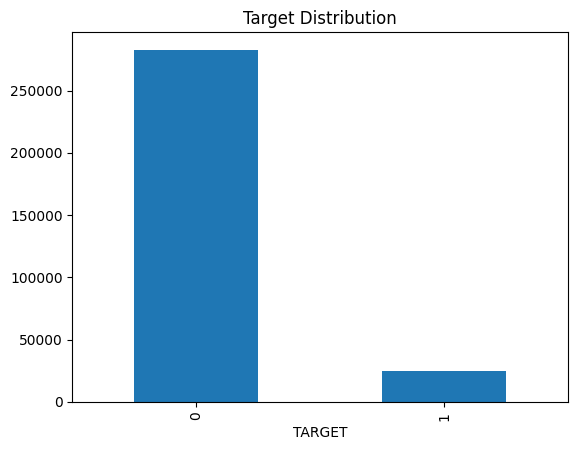

In [6]:
import matplotlib.pyplot as plt

train_df["TARGET"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Target Distribution"
)

plt.show()

### 📌 Findings

After inspecting the datasets, several important observations become clear.

#### Dataset Size

The project contains multiple large relational tables:

| Dataset | Rows |
|----------|----------:|
| application_train | 307,511 |
| application_test | 48,744 |
| bureau | 1.7M |
| bureau_balance | 27.2M |
| previous_application | 1.67M |
| installments_payments | 13.6M |
| POS_CASH_balance | 10.0M |
| credit_card_balance | 3.84M |

The auxiliary datasets are significantly larger than the main application dataset, which indicates that historical customer behavior will likely provide valuable predictive information.

---

#### Missing Values

Several features contain a very high percentage of missing values.

Examples:

- COMMONAREA_AVG → ~70%
- NONLIVINGAPARTMENTS_MEDI → ~69%
- LIVINGAPARTMENTS_AVG → ~68%
- YEARS_BUILD_AVG → ~66%
- OWN_CAR_AGE → ~66%

This suggests that:

- Missing values are a natural part of the dataset.
- Removing rows would result in substantial information loss.
- Missing values should be handled carefully during preprocessing rather than simply dropping observations.

---

#### Target Distribution

The target variable is highly imbalanced.

| Class | Percentage |
|---------|---------:|
| TARGET = 0 | 91.93% |
| TARGET = 1 | 8.07% |

This means that most customers successfully repay their loans, while only a small percentage experience payment difficulties.

Because of this imbalance:

- Accuracy is not an appropriate evaluation metric.
- ROC-AUC will be the primary metric.
- Precision, Recall, and F1 Score will also be monitored.

---

#### Initial Expectations

Based on the dataset structure, we expect that:

- Historical payment behavior will be highly predictive.
- Previous loan history will provide strong signals.
- External credit bureau information will be extremely important.
- Feature engineering will have a larger impact than model selection alone.

These hypotheses will be tested throughout the project.

# 🧹 3. Data Cleaning & Preprocessing

Before building any machine learning model, the data must be cleaned and standardized.

The objective of this stage is to:

- Reduce memory usage
- Handle abnormal values
- Analyze missing data
- Encode categorical variables
- Prepare train and test datasets
- Ensure model compatibility

Since the Home Credit dataset contains millions of records across multiple tables, efficient preprocessing is essential for both performance and stability.

## Memory Optimization

Several auxiliary tables contain millions of rows.

To reduce RAM consumption and improve processing speed, numerical columns are downcasted to smaller data types whenever possible.

This step does not change the underlying information but makes the dataset significantly more efficient to work with.

In [7]:
def reduce_mem_usage(df):

    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:

        col_type = df[col].dtype

        if str(col_type)[:3] in ['int', 'flo']:

            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':

                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)

                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)

                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            else:

                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2

    print(f"Memory Usage: {start_mem:.2f} MB -> {end_mem:.2f} MB")

    return df

### 📌 Findings

The auxiliary datasets contain millions of records.

Without memory optimization, feature engineering and aggregation steps become significantly slower.

Reducing memory usage allows faster experimentation while preserving the original information.

## Missing Values Analysis

Missing values are common throughout the Home Credit dataset.

Rather than immediately removing observations, we first investigate the amount and distribution of missing data.

In many real-world credit datasets, missing values themselves can contain useful information.

In [8]:
missing_summary = pd.DataFrame({

    "Missing_Count":
    train_df.isnull().sum(),

    "Missing_Percentage":
    train_df.isnull().mean()*100

})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]

missing_summary.sort_values(
    "Missing_Percentage",
    ascending=False
).head(20)

,Missing_Count,Missing_Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


### 📌 Findings

The missing value analysis reveals several important characteristics of the dataset.

#### High Missingness Features

Many housing-related variables contain a large percentage of missing values:

| Feature Group | Missing % |
|---------------|-----------:|
| COMMONAREA_* | ~70% |
| NONLIVINGAPARTMENTS_* | ~69% |
| LIVINGAPARTMENTS_* | ~68% |
| FLOORSMIN_* | ~68% |
| YEARS_BUILD_* | ~66% |
| OWN_CAR_AGE | ~66% |

This indicates that detailed property information is unavailable for a large portion of customers.

---

#### Missing Values Are Not Random

The concentration of missing values within specific feature groups suggests that the missingness is systematic rather than random.

For example:

- Customers without registered property information tend to have missing apartment-related variables.
- Customers without a registered vehicle naturally have missing values in `OWN_CAR_AGE`.

Therefore, missing values may carry useful information about customer characteristics.

---

#### Impact on Modeling

Dropping rows is not a viable solution because many important features contain missing values for more than half of the observations.

Instead:

- Missing values will be preserved whenever possible.
- Tree-based models such as LightGBM, XGBoost, and CatBoost can naturally handle missing values.
- Additional engineered features may later capture missingness patterns if they prove informative.

---

#### Initial Observation

At this stage, there is no evidence that these features should be removed.

Although they contain many missing values, some of them may still provide predictive information once the model begins learning customer behavior patterns.

## Handling Abnormal Values

Certain variables contain placeholder values instead of real observations.

One well-known example is DAYS_EMPLOYED, where the value 365243 represents a missing or unknown employment duration.

These placeholder values must be replaced before modeling.

In [9]:
train_df['DAYS_EMPLOYED'].replace(
    365243,
    np.nan,
    inplace=True
)

test_df['DAYS_EMPLOYED'].replace(
    365243,
    np.nan,
    inplace=True
)

0       -2329.0
1       -4469.0
2       -4458.0
3       -1866.0
4       -2191.0
          ...  
48739   -5169.0
48740   -1149.0
48741   -3037.0
48742   -2731.0
48743    -633.0
Name: DAYS_EMPLOYED, Length: 48744, dtype: float64

In [10]:
print(
    train_df['DAYS_EMPLOYED'].max()
)

365243


### 📌 Findings

The value 365243 is not a realistic employment duration.

Replacing it with missing values prevents the model from learning artificial patterns that do not represent actual customer behavior.

## Categorical Variables

The dataset contains both numerical and categorical variables.

Before encoding, categorical columns are identified so that they can be transformed into machine-learning compatible representations.

In [11]:
categorical_cols = train_df.select_dtypes(
    include=['object']
).columns

print(
    f"Number of Categorical Features: {len(categorical_cols)}"
)

categorical_cols.tolist()

Number of Categorical Features: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

## One-Hot Encoding

Tree-based models can handle numerical variables directly, but categorical features must first be transformed.

One-Hot Encoding converts each category into a binary indicator variable.

In [12]:
train_df = pd.get_dummies(
    train_df
)

test_df = pd.get_dummies(
    test_df
)

## Dataset Alignment

After encoding, train and test datasets may contain different columns.

To ensure consistency, both datasets are aligned before model training.

In [13]:
train_labels = train_df['TARGET']

train_df, test_df = train_df.align(
    test_df,
    join='inner',
    axis=1
)

train_df['TARGET'] = train_labels

### 📌 Findings

After one-hot encoding, some categories appear only in train or only in test.

Alignment guarantees that both datasets contain identical feature spaces before model training.

## Feature Name Cleanup

Some machine learning libraries are sensitive to special characters in feature names.

To ensure compatibility across all models, feature names are standardized by removing unsupported characters.

In [14]:
import re

def clean_columns(df):

    df = df.copy()

    df.columns = [

        re.sub(
            r'[^A-Za-z0-9_]+',
            '_',
            str(col)
        )

        for col in df.columns
    ]

    return df

In [15]:
train_df = clean_columns(train_df)
test_df = clean_columns(test_df)

### 📌 Findings

Standardized feature names improve compatibility across LightGBM, XGBoost, CatBoost, and SHAP.

This step helps prevent unexpected training and inference errors later in the pipeline.

# 🔍 4. Exploratory Data Analysis

Before starting feature engineering, it is useful to understand the most important variables available in the application dataset.

In this section we focus on:

- External risk scores
- Credit related variables
- Customer age
- Feature correlations

The goal is not exhaustive analysis, but rather identifying patterns that may help explain future model behavior.

## EXT_SOURCE Features

The dataset contains three external risk scores:

- EXT_SOURCE_1
- EXT_SOURCE_2
- EXT_SOURCE_3

Although their exact definitions are not publicly available, they represent externally calculated customer risk indicators.

These variables are expected to be among the strongest predictors of default risk.

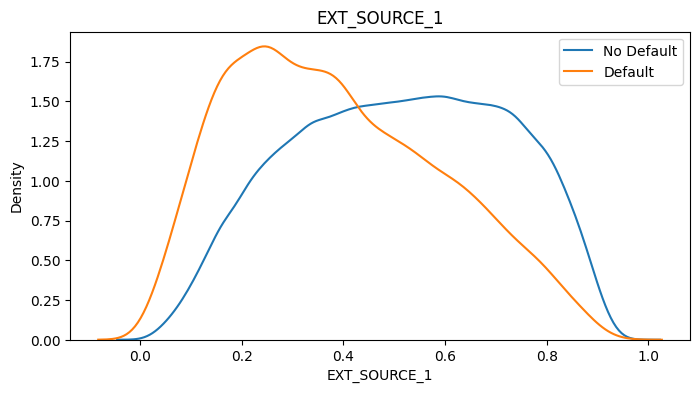

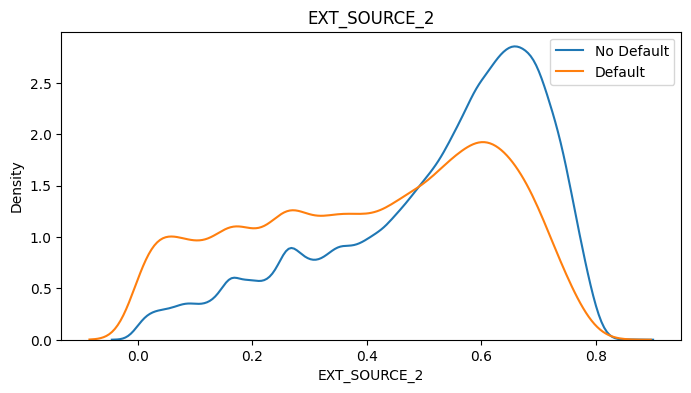

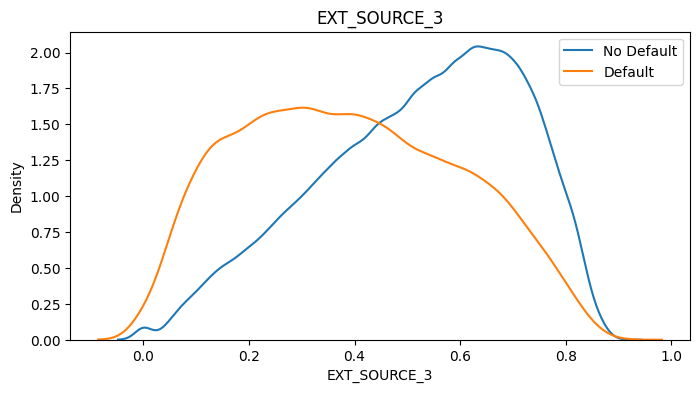

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

ext_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

for feature in ext_features:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        train_df.loc[
            train_df["TARGET"] == 0,
            feature
        ],
        label="No Default"
    )

    sns.kdeplot(
        train_df.loc[
            train_df["TARGET"] == 1,
            feature
        ],
        label="Default"
    )

    plt.title(feature)

    plt.legend()

    plt.show()

### 📌 Findings

All three EXT_SOURCE variables show clear separation between the two target classes.

Customers with lower EXT_SOURCE values tend to have a higher probability of default.

Even before model training, these features appear highly predictive and are likely to play a major role in the final model.

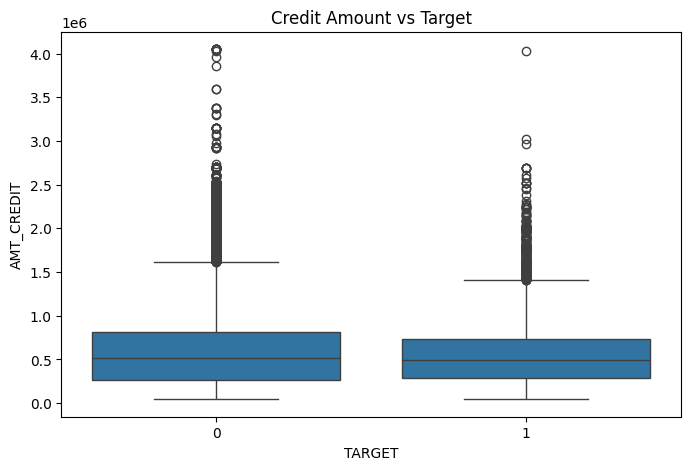

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="TARGET",
    y="AMT_CREDIT",
    data=train_df
)

plt.title(
    "Credit Amount vs Target"
)

plt.show()

### 📌 Findings

The distribution of loan amounts is relatively similar across both target classes.

Several observations can be made:

- Both groups have comparable median credit amounts.
- A large number of outliers exist in both classes.
- Customers with very large loans appear in both defaulted and non-defaulted groups.
- There is substantial overlap between the two distributions.

This suggests that loan amount alone is not a strong predictor of default risk.

Instead, the relationship between credit amount and other financial variables is likely to be more informative.

This observation motivates the creation of ratio-based features such as:

- CREDIT_TO_ANNUITY_RATIO
- CREDIT_GOODS_RATIO
- PAYMENT_RATE
- ANNUITY_INCOME_RATIO

These engineered features capture repayment burden more effectively than the raw credit amount itself.

## Annuity Analysis

The annuity represents the periodic payment expected from the customer.

Studying annuity distributions helps evaluate repayment burden.

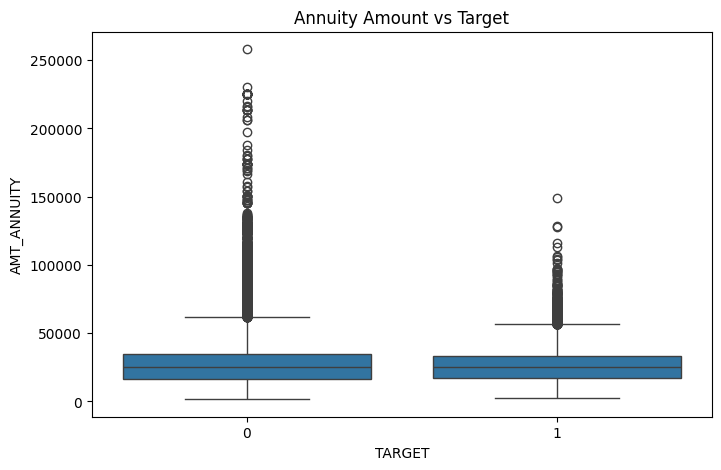

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="TARGET",
    y="AMT_ANNUITY",
    data=train_df
)

plt.title(
    "Annuity Amount vs Target"
)

plt.show()

### 📌 Findings

Annuity values vary widely across customers.

The relationship appears stronger when combined with income and credit information, motivating the creation of ratio-based features later in the project.

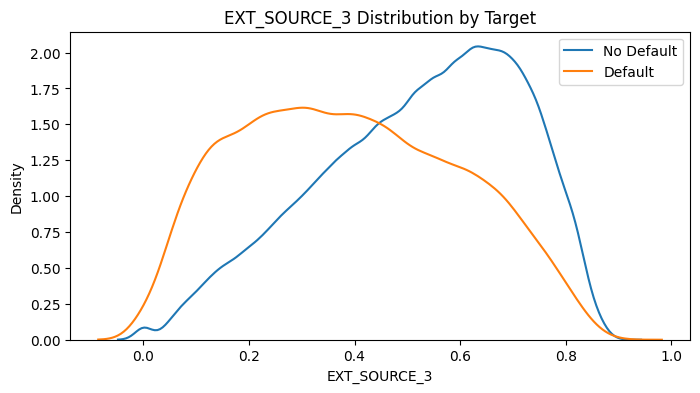

In [19]:
train_df["AGE_YEARS"] = (
    -train_df["DAYS_BIRTH"] / 365
)

# Compare feature distribution between
# customers who defaulted and those who did not

plt.figure(figsize=(8,4))

# TARGET = 0 (No Payment Difficulties)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        feature
    ],
    label="No Default"
)

# TARGET = 1 (Payment Difficulties)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        feature
    ],
    label="Default"
)

plt.title(
    f"{feature} Distribution by Target"
)

plt.legend()

plt.show()

### 📌 Findings

Younger customers tend to exhibit slightly higher default rates.

The difference is not large enough to act as a standalone predictor, but age may still provide useful information when combined with other financial variables.

## Correlation Analysis

Finally, we examine correlations between numerical features and the target variable.

This helps identify variables that may already contain useful predictive signals.

In [20]:
# Calculate correlation of all numeric features
# with the target variable

correlations = train_df.corr(
    numeric_only=True
)["TARGET"].sort_values()

# Features most negatively correlated
display(
    correlations.head(10)
)

# Features most positively correlated
display(
    correlations.tail(10)
)


EXT_SOURCE_3                           -0.178919
EXT_SOURCE_2                           -0.160472
EXT_SOURCE_1                           -0.155317
AGE_YEARS                              -0.078239
NAME_EDUCATION_TYPE_Higher_education   -0.056593
CODE_GENDER_F                          -0.054704
NAME_INCOME_TYPE_Pensioner             -0.046209
ORGANIZATION_TYPE_XNA                  -0.045987
DAYS_EMPLOYED                          -0.044932
FLOORSMAX_AVG                          -0.044003
Name: TARGET, dtype: float64

NAME_EDUCATION_TYPE_Secondary_secondary_special    0.049824
REG_CITY_NOT_WORK_CITY                             0.050994
DAYS_ID_PUBLISH                                    0.051457
CODE_GENDER_M                                      0.054713
DAYS_LAST_PHONE_CHANGE                             0.055218
NAME_INCOME_TYPE_Working                           0.057481
REGION_RATING_CLIENT                               0.058899
REGION_RATING_CLIENT_W_CITY                        0.060893
DAYS_BIRTH                                         0.078239
TARGET                                             1.000000
Name: TARGET, dtype: float64

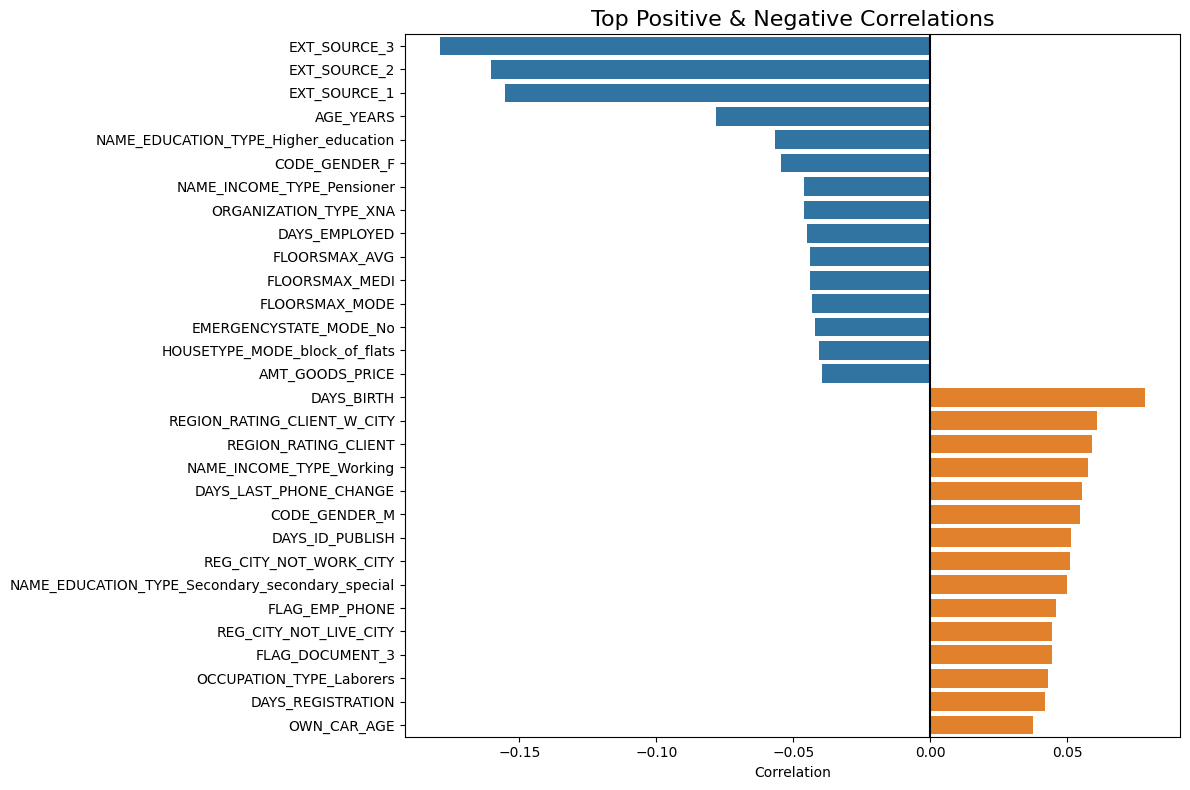

In [21]:
corr = correlations.drop("TARGET")

top_features = pd.concat([
    corr.nsmallest(15),
    corr.nlargest(15)
])

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    hue=top_features.values > 0,
    dodge=False,
    legend=False
)

plt.axvline(0, color='black')
plt.title("Top Positive & Negative Correlations", fontsize=16)
plt.xlabel("Correlation")
plt.ylabel("")

plt.tight_layout()
plt.show()

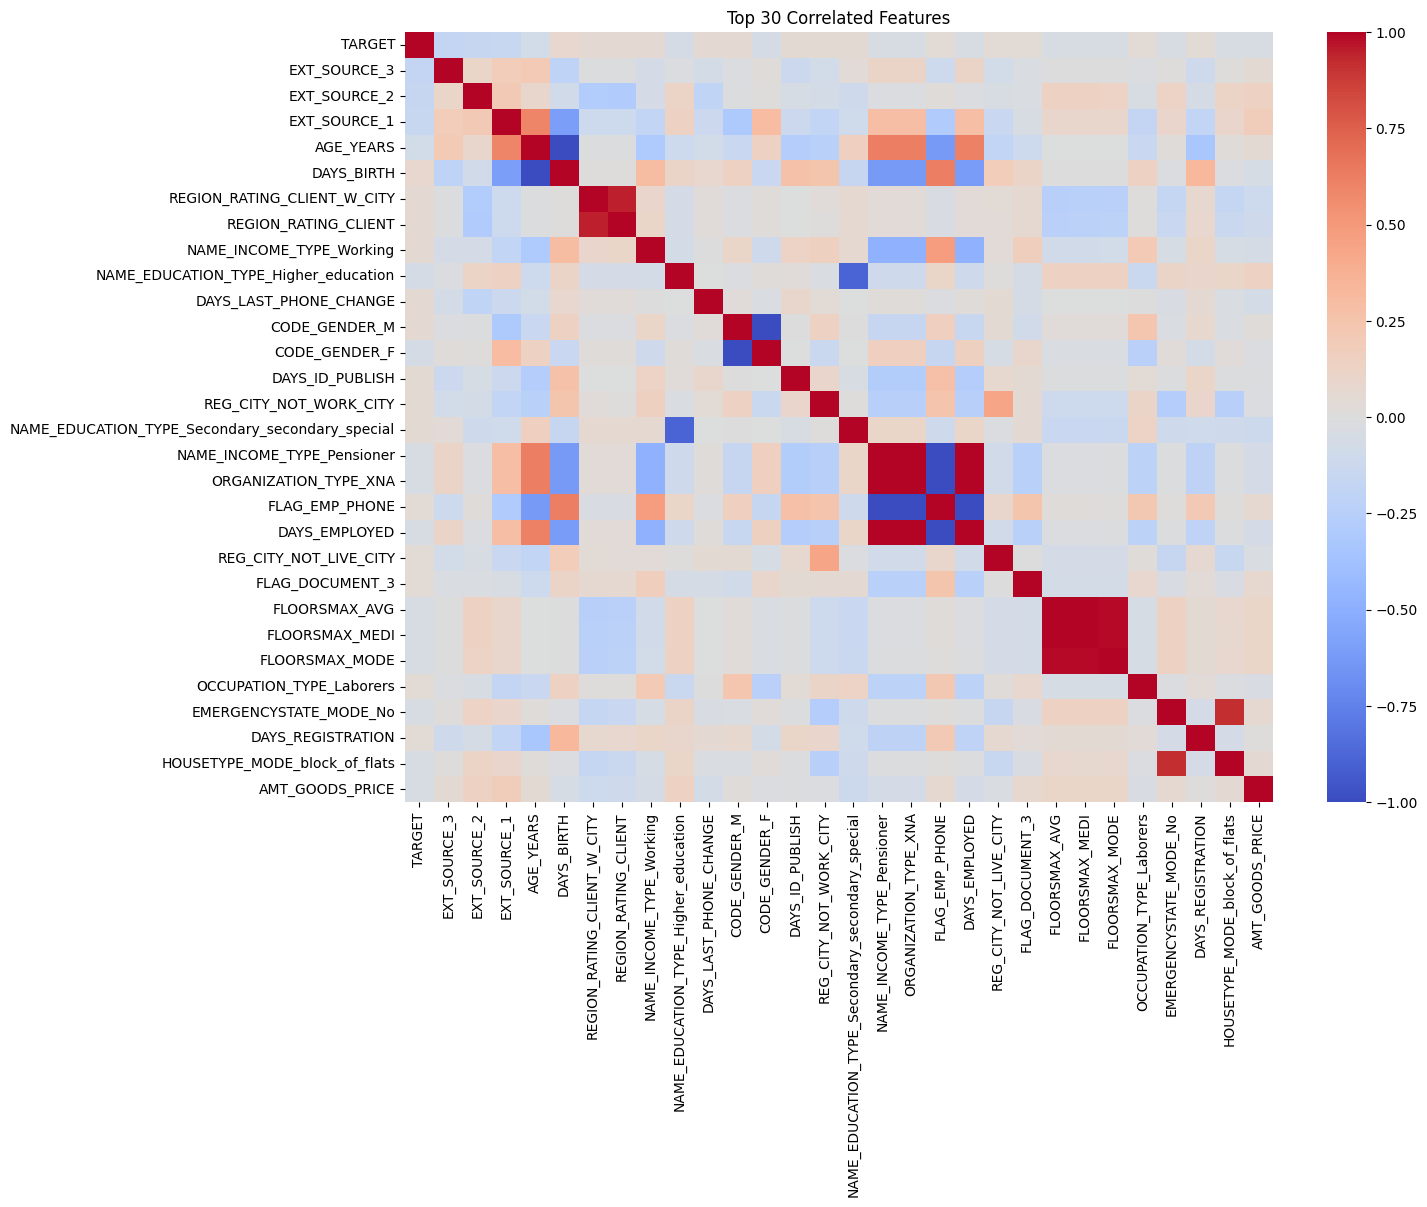

In [22]:
top_features = correlations.abs().sort_values(
    ascending=False
).head(30).index

plt.figure(figsize=(14,10))

sns.heatmap(
    train_df[top_features].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Top 30 Correlated Features")
plt.show()

### 📌 Findings

The correlation analysis reveals several early signals related to default risk.

#### Strong Negative Correlations

The strongest negative correlations are observed for:

- EXT_SOURCE_3
- EXT_SOURCE_2
- EXT_SOURCE_1
- AGE_YEARS

Higher values of these features are associated with lower default probability.

This suggests that customers with stronger external risk scores and older age tend to be less risky borrowers.

---

#### Strong Positive Correlations

The strongest positive correlations include:

- DAYS_BIRTH
- REGION_RATING_CLIENT
- REGION_RATING_CLIENT_W_CITY
- DAYS_LAST_PHONE_CHANGE
- DAYS_ID_PUBLISH

Higher values of these variables are associated with increased default risk.

These features may indirectly capture customer stability, documentation history, or regional risk characteristics.

---

#### Correlation Strength

Although some variables show meaningful relationships with the target, the absolute correlation values remain relatively small.

The strongest feature (`EXT_SOURCE_3`) has a correlation of approximately:

-0.18

This indicates that no single feature can explain default behavior on its own.

Instead, the final predictive power is expected to come from combining information across multiple datasets and engineered features.

---

#### Interesting Observation

The three external risk scores (`EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3`) already appear among the most informative variables.

This observation is later confirmed during model training, where these features become the most important predictors according to both LightGBM feature importance and SHAP analysis.

## EDA Summary

The exploratory analysis highlights several important observations:

- The dataset is highly imbalanced.
- EXT_SOURCE variables appear extremely predictive.
- Raw financial variables alone provide limited separation.
- Age contributes useful but modest information.
- Behavioral information is likely to be more valuable than demographic information.

These observations motivate the extensive feature engineering process that follows.

# 🧠 5. Feature Engineering

Raw application features provide useful information about customers.

However, many financial relationships are not directly represented in the original dataset.

To better capture customer risk profiles, several domain-inspired features were engineered using ratios and behavioral indicators.

The objective is to transform raw variables into features that better represent:

- Repayment burden
- Financial capacity
- Employment stability
- Customer maturity
- Credit utilization patterns

These engineered features later become some of the most important predictors in the final model.

## 5.1 Application Features

The first set of engineered features is created directly from the main application dataset.

Most of these variables are financial ratios that describe relationships between credit amount, income, annuity payments, age, and employment history.

Ratio-based features are often more informative than raw values because they provide context about a customer's financial situation.

### AGE_YEARS

The original dataset stores age as the number of days before the application date.

For easier interpretation, age is converted into years.

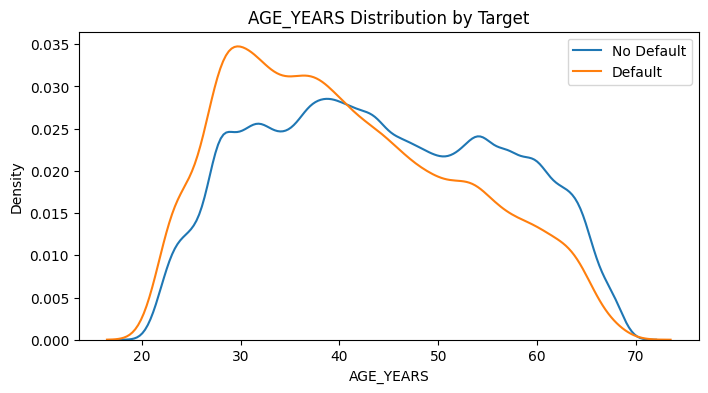

In [23]:
# Convert age from negative days to years

train_df["AGE_YEARS"] = (
    -train_df["DAYS_BIRTH"] / 365
)

test_df["AGE_YEARS"] = (
    -test_df["DAYS_BIRTH"] / 365
)
plt.figure(figsize=(8,4))
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        "AGE_YEARS"
    ],
    label="No Default"
)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        "AGE_YEARS"
    ],
    label="Default"
)
plt.title("AGE_YEARS Distribution by Target")
plt.legend()
plt.show()

### PAYMENT_RATE

This feature measures the proportion of the total credit that must be paid during each annuity period.

It provides an estimate of repayment burden.

Higher values may indicate more aggressive repayment schedules.

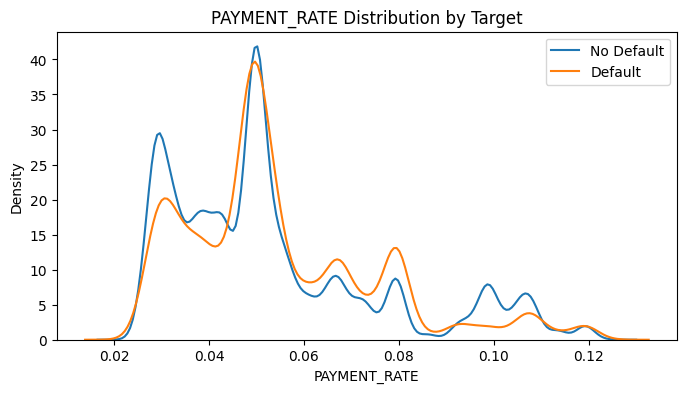

In [24]:
# Monthly payment relative to total credit

train_df["PAYMENT_RATE"] = (
    train_df["AMT_ANNUITY"] /
    train_df["AMT_CREDIT"]
)

test_df["PAYMENT_RATE"] = (
    test_df["AMT_ANNUITY"] /
    test_df["AMT_CREDIT"]
)

plt.figure(figsize=(8,4))
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        "PAYMENT_RATE"
    ],
    label="No Default"
)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        "PAYMENT_RATE"
    ],
    label="Default"
)
plt.title("PAYMENT_RATE Distribution by Target")
plt.legend()
plt.show()

### CREDIT_TO_ANNUITY_RATIO

This feature compares total loan amount to periodic annuity payments.

It approximates the effective repayment horizon of the loan.

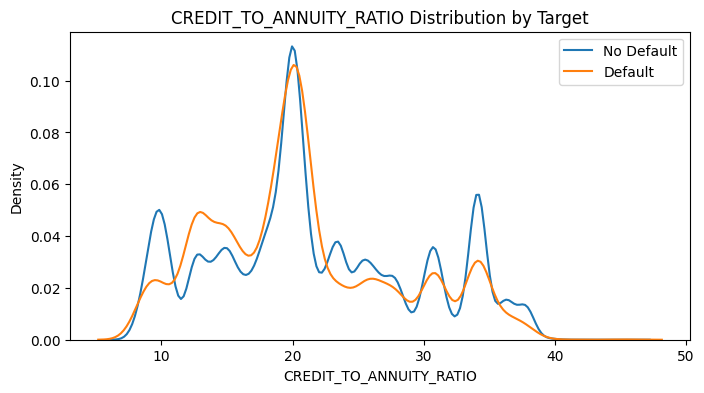

In [25]:
# Credit amount relative to annuity payment

train_df["CREDIT_TO_ANNUITY_RATIO"] = (
    train_df["AMT_CREDIT"] /
    train_df["AMT_ANNUITY"]
)

test_df["CREDIT_TO_ANNUITY_RATIO"] = (
    test_df["AMT_CREDIT"] /
    test_df["AMT_ANNUITY"]
)

plt.figure(figsize=(8,4))
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        "CREDIT_TO_ANNUITY_RATIO"
    ],
    label="No Default"
)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        "CREDIT_TO_ANNUITY_RATIO"
    ],
    label="Default"
)
plt.title("CREDIT_TO_ANNUITY_RATIO Distribution by Target")
plt.legend()
plt.show()

### ANNUITY_INCOME_RATIO

This feature measures how much of a customer's income is required to cover annuity payments.

It acts as a proxy for financial stress.

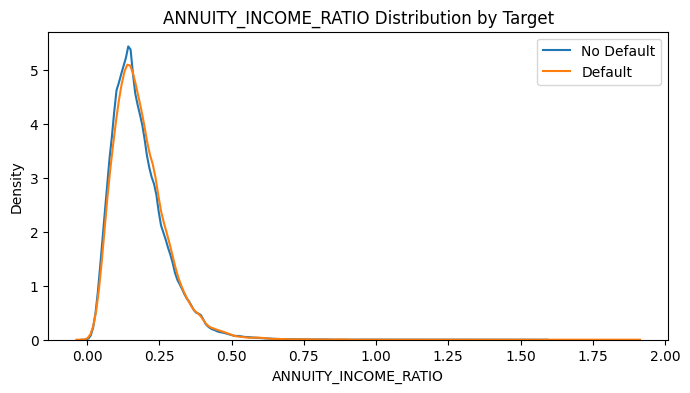

In [26]:
# Payment burden relative to income

train_df["ANNUITY_INCOME_RATIO"] = (
    train_df["AMT_ANNUITY"] /
    train_df["AMT_INCOME_TOTAL"]
)

test_df["ANNUITY_INCOME_RATIO"] = (
    test_df["AMT_ANNUITY"] /
    test_df["AMT_INCOME_TOTAL"]
)

plt.figure(figsize=(8,4))
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        "ANNUITY_INCOME_RATIO"
    ],
    label="No Default"
)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        "ANNUITY_INCOME_RATIO"
    ],
    label="Default"
)
plt.title("ANNUITY_INCOME_RATIO Distribution by Target")
plt.legend()
plt.show()

### EMPLOYED_AGE_RATIO

This feature measures employment duration relative to customer age.

It provides a simple indicator of employment stability.

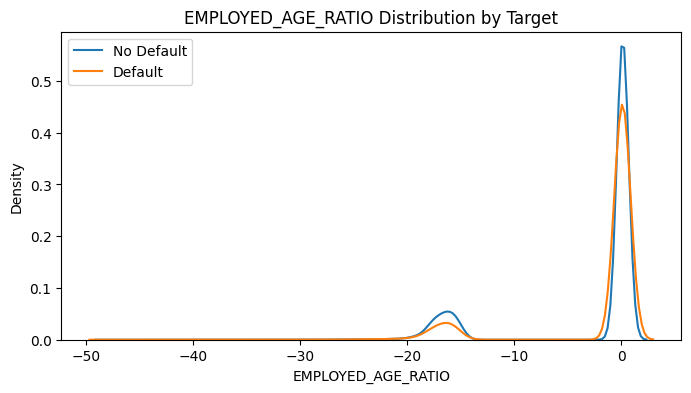

In [27]:
# Employment history relative to age

train_df["EMPLOYED_AGE_RATIO"] = (
    train_df["DAYS_EMPLOYED"] /
    train_df["DAYS_BIRTH"]
)

test_df["EMPLOYED_AGE_RATIO"] = (
    test_df["DAYS_EMPLOYED"] /
    test_df["DAYS_BIRTH"]
)

plt.figure(figsize=(8,4))
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        "EMPLOYED_AGE_RATIO"
    ],
    label="No Default"
)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        "EMPLOYED_AGE_RATIO"
    ],
    label="Default"
)
plt.title("EMPLOYED_AGE_RATIO Distribution by Target")
plt.legend()
plt.show()

### CAR_TO_BIRTH_RATIO

This feature relates vehicle ownership duration to customer age.

It may indirectly capture financial maturity and asset ownership stability.

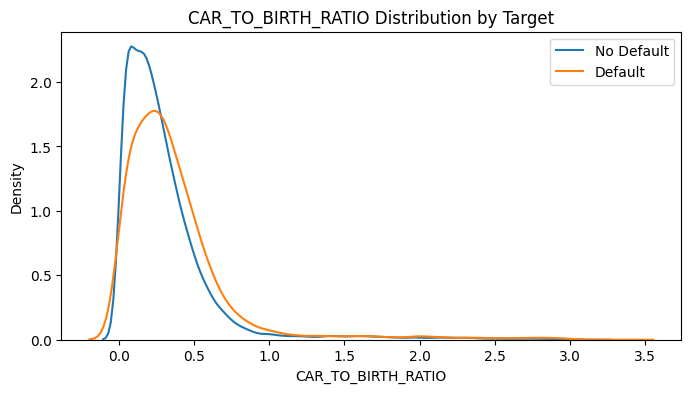

In [28]:
# Vehicle age relative to customer age

train_df["CAR_TO_BIRTH_RATIO"] = (
    train_df["OWN_CAR_AGE"] /
    train_df["AGE_YEARS"]
)

test_df["CAR_TO_BIRTH_RATIO"] = (
    test_df["OWN_CAR_AGE"] /
    test_df["AGE_YEARS"]
)

plt.figure(figsize=(8,4))
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        "CAR_TO_BIRTH_RATIO"
    ],
    label="No Default"
)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        "CAR_TO_BIRTH_RATIO"
    ],
    label="Default"
)
plt.title("CAR_TO_BIRTH_RATIO Distribution by Target")
plt.legend()
plt.show()

### PHONE_CHANGE_PERCENT

This feature measures how recently the customer changed their phone number relative to age.

Frequent changes may indicate lower stability.

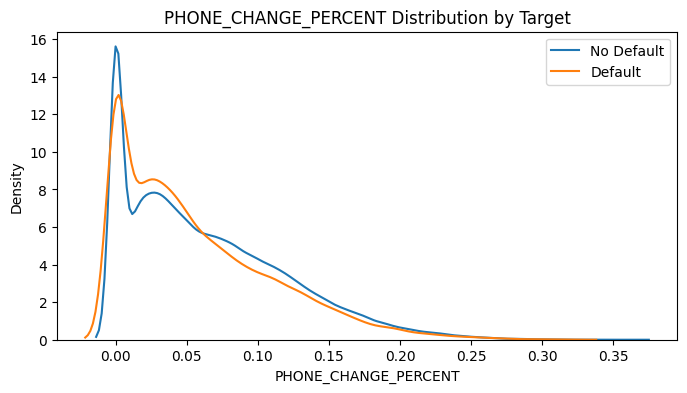

In [29]:
# Phone change history relative to age

train_df["PHONE_CHANGE_PERCENT"] = (
    train_df["DAYS_LAST_PHONE_CHANGE"] /
    train_df["DAYS_BIRTH"]
)

test_df["PHONE_CHANGE_PERCENT"] = (
    test_df["DAYS_LAST_PHONE_CHANGE"] /
    test_df["DAYS_BIRTH"]
)

plt.figure(figsize=(8,4))
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        "PHONE_CHANGE_PERCENT"
    ],
    label="No Default"
)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        "PHONE_CHANGE_PERCENT"
    ],
    label="Default"
)
plt.title("PHONE_CHANGE_PERCENT Distribution by Target")
plt.legend()
plt.show()

### EMPLOYMENT_PERCENT

This feature compares employment duration to customer age.

It represents the proportion of life spent in employment.

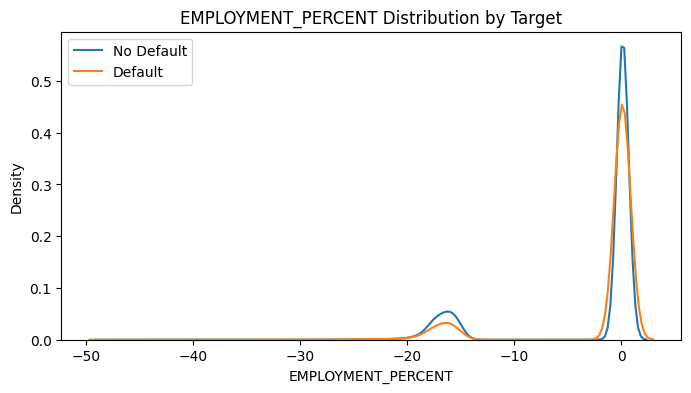

In [30]:
# Employment duration relative to age

train_df["EMPLOYMENT_PERCENT"] = (
    train_df["DAYS_EMPLOYED"] /
    train_df["DAYS_BIRTH"]
)

test_df["EMPLOYMENT_PERCENT"] = (
    test_df["DAYS_EMPLOYED"] /
    test_df["DAYS_BIRTH"]
)
plt.figure(figsize=(8,4))
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 0,
        "EMPLOYMENT_PERCENT"
    ],
    label="No Default"
)
sns.kdeplot(
    train_df.loc[
        train_df["TARGET"] == 1,
        "EMPLOYMENT_PERCENT"
    ],
    label="Default"
)
plt.title("EMPLOYMENT_PERCENT Distribution by Target")
plt.legend()
plt.show()

#### 📌 Application Features Findings

Several engineered features show noticeable differences between defaulted and non-defaulted customers.

### AGE_YEARS

The age distribution reveals a clear pattern:

- Customers who default tend to be younger.
- Older customers generally exhibit lower default rates.
- The separation is not large, but it is consistent across the distribution.

This supports the inclusion of age-related features in the model.

---

### PAYMENT_RATE

PAYMENT_RATE shows visible separation between the two groups.

Customers with higher repayment burden tend to appear more frequently in the default class.

This indicates that repayment pressure may be an important risk factor.

The feature later becomes one of the most important engineered variables in the final model.

---

### CREDIT_TO_ANNUITY_RATIO

The distribution differs across several regions of the feature space.

Although the separation is moderate, the feature captures information that is not available from either credit amount or annuity amount alone.

This explains why it later ranks among the strongest features in the model.

---

### ANNUITY_INCOME_RATIO

The distributions largely overlap.

While the feature alone does not strongly separate the two classes, it still provides useful information when combined with other financial variables.

Tree-based models are often able to exploit such interactions even when individual separation appears weak.

---

### EMPLOYED_AGE_RATIO

A small but consistent difference is visible between the two groups.

Customers with longer employment history relative to their age generally appear less risky.

This feature acts as a proxy for employment stability.

---

### PHONE_CHANGE_PERCENT

The distributions show mild separation.

Customers who recently changed their phone numbers appear slightly more represented in the default class.

Although the effect is not strong, it may capture behavioral stability signals.

---

### CAR_TO_BIRTH_RATIO

The default class exhibits slightly higher values across part of the distribution.

The feature alone is not highly predictive, but it may contribute additional information when combined with other demographic and financial variables.

---

### Overall Conclusion

Most engineered features do not create perfect class separation on their own.

However, they introduce useful signals related to:

- Repayment burden
- Financial capacity
- Employment stability
- Customer maturity
- Behavioral consistency

This is precisely the type of information that gradient boosting models such as LightGBM can combine effectively to improve predictive performance.

## 5.2 Bureau Features

The bureau dataset contains historical credit records collected from external credit institutions.

While the application dataset describes the current loan request, the bureau dataset provides information about the customer's previous borrowing behavior.

This additional historical context can significantly improve credit risk assessment.

The main objective was to transform multiple bureau records per customer into customer-level aggregated features.

This information can help answer questions such as:

- Has the customer borrowed before?
- How many credits are currently active?
- How much debt does the customer owe?
- How long has the customer been using credit?
- Does the customer have a history of credit problems?

Since a customer may have multiple bureau records, aggregation is required before merging the data with the main application dataset.

### Bureau Dataset
Each row in the bureau dataset represents a historical credit record associated with a customer.

A single customer can appear multiple times because they may have had several previous loans or credit products.

Therefore, customer-level features must be created using aggregation techniques.

In [31]:
# Basic bureau information

print(bureau.shape)

bureau.head()

(1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


### Bureau Dataset Overview

Each row in the bureau dataset represents a previous credit record associated with a customer.

Dataset Shape:

- Rows: 1,716,428
- Columns: 17

Since a customer can have multiple bureau records, aggregation was required before merging with the main application dataset.

Important variables include:

- CREDIT_ACTIVE
- DAYS_CREDIT
- AMT_CREDIT_SUM
- AMT_CREDIT_SUM_DEBT
- DAYS_CREDIT_ENDDATE
- DAYS_ENDDATE_FACT

These variables describe historical borrowing activity, debt exposure, and credit timelines.

### Basic Bureau Aggregations

The first step is to summarize bureau information at the customer level.

Several statistics are calculated for each customer, including:

- Mean values
- Maximum values
- Minimum values
- Sum values

These aggregated features provide a compact representation of historical credit behavior.

In [32]:
# Customer-level bureau aggregations

bureau_agg = bureau.groupby(
    "SK_ID_CURR"
).agg({

    "DAYS_CREDIT": [
        "mean",
        "min",
        "max"
    ],

    "AMT_CREDIT_SUM": [
        "mean",
        "sum",
        "max"
    ],

    "AMT_CREDIT_SUM_DEBT": [
        "mean",
        "sum",
        "max"
    ]

})

bureau_agg.columns = [

    "BUREAU_" + "_".join(col)

    for col in bureau_agg.columns
]

bureau_agg = bureau_agg.reset_index()

bureau_agg.head()

,SK_ID_CURR,BUREAU_DAYS_CREDIT_mean,BUREAU_DAYS_CREDIT_min,BUREAU_DAYS_CREDIT_max,BUREAU_AMT_CREDIT_SUM_mean,BUREAU_AMT_CREDIT_SUM_sum,BUREAU_AMT_CREDIT_SUM_max,BUREAU_AMT_CREDIT_SUM_DEBT_mean,BUREAU_AMT_CREDIT_SUM_DEBT_sum,BUREAU_AMT_CREDIT_SUM_DEBT_max
0,100001,-735.000000,-1572,-49,207623.571429,1453365.000,378000.0,85240.928571,596686.5,373239.0
1,100002,-874.000000,-1437,-103,108131.945625,865055.565,450000.0,49156.200000,245781.0,245781.0
2,100003,-1400.750000,-2586,-606,254350.125000,1017400.500,810000.0,0.000000,0.0,0.0
3,100004,-867.000000,-1326,-408,94518.900000,189037.800,94537.8,0.000000,0.0,0.0
4,100005,-190.666667,-373,-62,219042.000000,657126.000,568800.0,189469.500000,568408.5,543087.0


### 📌 Findings

These features summarize the customer's overall credit history.

Examples:

- Average historical credit amount
- Total credit exposure
- Total debt exposure
- Length of credit history

The resulting features provide a much richer view of customer borrowing behavior than the application data alone.

### Active Loans Features

Current active credits can indicate ongoing financial obligations.

To capture this information, only records with:

CREDIT_ACTIVE = Active

were selected and aggregated.

In [33]:
# Active loans only

active = bureau[
    bureau["CREDIT_ACTIVE"] == "Active"
]

active_agg = active.groupby(
    "SK_ID_CURR"
).agg({

    "AMT_CREDIT_SUM": [
        "mean",
        "sum"
    ],

    "AMT_CREDIT_SUM_DEBT": [
        "mean",
        "sum"
    ]

})

active_agg.columns = [

    "ACTIVE_" + "_".join(col)

    for col in active_agg.columns
]

active_agg = active_agg.reset_index()

active_agg.head()

,SK_ID_CURR,ACTIVE_AMT_CREDIT_SUM_mean,ACTIVE_AMT_CREDIT_SUM_sum,ACTIVE_AMT_CREDIT_SUM_DEBT_mean,ACTIVE_AMT_CREDIT_SUM_DEBT_sum
0,100001,294675.0000,884025.000,198895.50,596686.5
1,100002,240994.2825,481988.565,122890.50,245781.0
2,100003,810000.0000,810000.000,0.00,0.0
3,100005,299313.0000,598626.000,284204.25,568408.5
4,100008,267606.0000,267606.000,240057.00,240057.0


### 📌 Findings

Active loan features estimate the customer's current debt burden.

Examples:

- Current total debt
- Average active credit size
- Total active credit exposure

These features help quantify how much financial obligation currently exists.

### Closed Loans Features

Completed credits can provide useful information about previous borrowing experience.

Only records with:

CREDIT_ACTIVE = Closed

were aggregated.

In [34]:
# Closed loans only

closed = bureau[
    bureau["CREDIT_ACTIVE"] == "Closed"
]

closed_agg = closed.groupby(
    "SK_ID_CURR"
).agg({

    "AMT_CREDIT_SUM": [
        "mean",
        "sum"
    ],

    "DAYS_CREDIT": [
        "mean",
        "max"
    ]

})

closed_agg.columns = [

    "CLOSED_" + "_".join(col)

    for col in closed_agg.columns
]

closed_agg = closed_agg.reset_index()

closed_agg.head()

,SK_ID_CURR,CLOSED_AMT_CREDIT_SUM_mean,CLOSED_AMT_CREDIT_SUM_sum,CLOSED_DAYS_CREDIT_mean,CLOSED_DAYS_CREDIT_max
0,100001,142335.0,569340.0,-1054.250000,-857
1,100002,63844.5,383067.0,-974.500000,-476
2,100003,69133.5,207400.5,-1665.666667,-775
3,100004,94518.9,189037.8,-867.000000,-408
4,100005,58500.0,58500.0,-373.000000,-373


### 📌 Findings

Closed credit features capture previous borrowing history.

Customers with a long history of successfully completed loans may behave differently from customers with limited credit history.

### Debt Features

Outstanding debt is one of the most important financial risk indicators.

Additional features were created using debt-related variables.

In [35]:
# Debt-related statistics

debt_agg = bureau.groupby(
    "SK_ID_CURR"
).agg({

    "AMT_CREDIT_SUM_DEBT": [
        "mean",
        "sum",
        "max"
    ]

})

debt_agg.columns = [

    "DEBT_" + "_".join(col)

    for col in debt_agg.columns
]

debt_agg = debt_agg.reset_index()

debt_agg.head()

,SK_ID_CURR,DEBT_AMT_CREDIT_SUM_DEBT_mean,DEBT_AMT_CREDIT_SUM_DEBT_sum,DEBT_AMT_CREDIT_SUM_DEBT_max
0,100001,85240.928571,596686.5,373239.0
1,100002,49156.200000,245781.0,245781.0
2,100003,0.000000,0.0,0.0
3,100004,0.000000,0.0,0.0
4,100005,189469.500000,568408.5,543087.0


### 📌 Findings

Debt-based variables provide direct information about financial obligations.

Examples:

- Average debt amount
- Maximum debt observed
- Total outstanding debt

These features later became important contributors to model performance.

### Credit History Features

The length of a customer's credit history often reflects their experience with credit products.

To capture this information, DAYS_CREDIT statistics were aggregated.

In [36]:
# Credit history duration

duration_agg = bureau.groupby(
    "SK_ID_CURR"
).agg({

    "DAYS_CREDIT": [
        "mean",
        "min",
        "max"
    ]

})

duration_agg.columns = [

    "CREDIT_HISTORY_" + "_".join(col)

    for col in duration_agg.columns
]

duration_agg = duration_agg.reset_index()

duration_agg.head()

,SK_ID_CURR,CREDIT_HISTORY_DAYS_CREDIT_mean,CREDIT_HISTORY_DAYS_CREDIT_min,CREDIT_HISTORY_DAYS_CREDIT_max
0,100001,-735.000000,-1572,-49
1,100002,-874.000000,-1437,-103
2,100003,-1400.750000,-2586,-606
3,100004,-867.000000,-1326,-408
4,100005,-190.666667,-373,-62


### 📌 Findings

Credit history features estimate:

- Recency of borrowing activity
- Long-term credit experience
- Historical engagement with financial institutions

These variables provide additional behavioral information beyond application-level features.

### Merging Bureau Features

All bureau feature groups were merged into the application dataset using SK_ID_CURR.

This creates a unified customer-level dataset containing both application information and historical credit behavior.

In [37]:
# Merge bureau features

train_df = train_df.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how="left"
)

test_df = test_df.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how="left"
)

print(train_df.shape)
print(test_df.shape)
print(train_df.columns)
print(test_df.columns)
print(train_df.head())
print(test_df.head())
print("Bureau features merged successfully!")

(307511, 260)
(48744, 259)
Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'EMPLOYMENT_PERCENT', 'BUREAU_DAYS_CREDIT_mean',
       'BUREAU_DAYS_CREDIT_min', 'BUREAU_DAYS_CREDIT_max',
       'BUREAU_AMT_CREDIT_SUM_mean', 'BUREAU_AMT_CREDIT_SUM_sum',
       'BUREAU_AMT_CREDIT_SUM_max', 'BUREAU_AMT_CREDIT_SUM_DEBT_mean',
       'BUREAU_AMT_CREDIT_SUM_DEBT_sum', 'BUREAU_AMT_CREDIT_SUM_DEBT_max'],
      dtype='str', length=260)
Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'EMPLOYMENT_PERCENT', 'BUREAU_DAYS_CREDIT_mean',
       'BUREAU_DAYS_CREDIT_min', 'BUREAU_DAYS_CREDIT_max',
       'BUREAU_AMT_CREDIT_SUM_mean', 'BUREAU_AMT_CREDIT_SUM_sum',
       'B

## 📌 Bureau Features Summary

After merging bureau features:

Train Shape:
- (307511, 269)

Test Shape:
- (48744, 268)

The bureau dataset was the first external data source integrated into the project.

It introduced information about:

- Historical borrowing activity
- Outstanding debt
- Active loans
- Closed loans
- Credit history duration

These features provided significant additional context beyond the original application dataset and formed the foundation for later performance improvements.

## 5.3 Previous Applications

The previous_application dataset contains information about customers' past loan applications submitted to Home Credit.

Unlike the bureau dataset, which describes credit history from external institutions, this dataset reflects the customer's historical interactions with Home Credit itself.

These records provide valuable information about:

- Previous approvals
- Previous refusals
- Requested loan amounts
- Credit amounts granted
- Previous repayment schedules
- Historical application behavior

Since customers can have multiple previous applications, aggregation is required before merging the data with the main application dataset.

In [38]:
# Dataset shape

print(previous_application.shape)

previous_application.head()

(1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


### Basic Previous Application Aggregations

The first step is creating customer-level statistics from all historical applications.

These features summarize:

- Credit amounts
- Application amounts
- Previous decisions
- Repayment plans

In [39]:
# Customer-level aggregations

prev_agg = previous_application.groupby(
    "SK_ID_CURR"
).agg({

    "AMT_APPLICATION": [
        "mean",
        "max"
    ],

    "AMT_CREDIT": [
        "mean",
        "max"
    ],

    "CNT_PAYMENT": [
        "mean",
        "max"
    ],

    "DAYS_DECISION": [
        "mean",
        "max"
    ]

})

# Flatten column names

prev_agg.columns = [

    "PREV_" + "_".join(col)

    for col in prev_agg.columns

]

prev_agg = prev_agg.reset_index()

prev_agg.head()

,SK_ID_CURR,PREV_AMT_APPLICATION_mean,PREV_AMT_APPLICATION_max,PREV_AMT_CREDIT_mean,PREV_AMT_CREDIT_max,PREV_CNT_PAYMENT_mean,PREV_CNT_PAYMENT_max,PREV_DAYS_DECISION_mean,PREV_DAYS_DECISION_max
0,100001,24835.50,24835.5,23787.00,23787.0,8.0,8.0,-1740.0,-1740
1,100002,179055.00,179055.0,179055.00,179055.0,24.0,24.0,-606.0,-606
2,100003,435436.50,900000.0,484191.00,1035882.0,10.0,12.0,-1305.0,-746
3,100004,24282.00,24282.0,20106.00,20106.0,4.0,4.0,-815.0,-815
4,100005,22308.75,44617.5,20076.75,40153.5,12.0,12.0,-536.0,-315


### 📌 Findings

These features summarize the customer's historical borrowing behavior with Home Credit.

Examples:

- Average requested credit
- Average approved credit
- Typical repayment duration
- Historical application timing

### Approved Applications

Applications that were approved provide information about loans successfully granted in the past.

These records can reveal previous repayment commitments and borrowing patterns.

In [40]:
# Approved applications only

approved = previous_application[
    previous_application["NAME_CONTRACT_STATUS"] == "Approved"
]

approved_agg = approved.groupby(
    "SK_ID_CURR"
).agg({

    "CNT_PAYMENT": [
        "mean"
    ],

    "AMT_CREDIT": [
        "mean",
        "max"
    ]

})

approved_agg.columns = [

    "APPROVED_" + "_".join(col)

    for col in approved_agg.columns

]

approved_agg = approved_agg.reset_index()
print(approved_agg.head())

   SK_ID_CURR  APPROVED_CNT_PAYMENT_mean  APPROVED_AMT_CREDIT_mean  \
0      100001                        8.0                   23787.0   
1      100002                       24.0                  179055.0   
2      100003                       10.0                  484191.0   
3      100004                        4.0                   20106.0   
4      100005                       12.0                   40153.5   

   APPROVED_AMT_CREDIT_max  
0                  23787.0  
1                 179055.0  
2                1035882.0  
3                  20106.0  
4                  40153.5  


### 📌 Findings

Approved application features provide insight into previously granted loans.

They help estimate:

- Typical loan size
- Historical repayment schedules
- Borrowing capacity

### Refused Applications

Refused applications may indicate elevated risk or previous eligibility issues.

The frequency of refusals can provide an important risk signal.

In [41]:
# Refused applications

refused = previous_application[
    previous_application["NAME_CONTRACT_STATUS"] == "Refused"
]

refused_count = refused.groupby(
    "SK_ID_CURR"
).size()

refused_count = refused_count.reset_index(
    name="REFUSED_COUNT"
)
print(refused_count.head())

   SK_ID_CURR  REFUSED_COUNT
0      100006              1
1      100011              1
2      100027              1
3      100030             10
4      100035              8


### Refusal Ratio

Rather than using the number of refusals alone, a refusal ratio was created.

This measures the proportion of applications that ended in refusal.

In [42]:
# Total applications

total_apps = previous_application.groupby(
    "SK_ID_CURR"
).size()

# Refused applications

refused_apps = previous_application[
    previous_application["NAME_CONTRACT_STATUS"] == "Refused"
]

refused_apps = refused_apps.groupby(
    "SK_ID_CURR"
).size()

# Refusal ratio

refusal_ratio = (
    refused_apps
    /
    total_apps
)

refusal_ratio = refusal_ratio.fillna(0)

refusal_ratio = refusal_ratio.reset_index(
    name="PREV_REFUSAL_RATIO"
)
print(refusal_ratio.head())

   SK_ID_CURR  PREV_REFUSAL_RATIO
0      100001                 0.0
1      100002                 0.0
2      100003                 0.0
3      100004                 0.0
4      100005                 0.0


### 📌 Findings

The refusal ratio became one of the strongest previous application features.

Customers with a larger proportion of refused applications may represent higher credit risk.

### Previous Decision Features

Decision timing can capture recent customer interactions with Home Credit.

More recent applications may provide stronger signals than older historical records.

In [43]:
decision_agg = previous_application.groupby(
    "SK_ID_CURR"
).agg({

    "DAYS_DECISION": [
        "mean",
        "max"
    ]

})

decision_agg.columns = [

    "PREV_" + "_".join(col)

    for col in decision_agg.columns

]

decision_agg = decision_agg.reset_index()
print(decision_agg.head())

   SK_ID_CURR  PREV_DAYS_DECISION_mean  PREV_DAYS_DECISION_max
0      100001                  -1740.0                   -1740
1      100002                   -606.0                    -606
2      100003                  -1305.0                    -746
3      100004                   -815.0                    -815
4      100005                   -536.0                    -315


### Last Approved Decision

The most recent approved application was extracted separately.

Recent behavior often carries more predictive information than older records.

In [44]:
approved_sorted = approved.sort_values(
    "DAYS_DECISION",
    ascending=False
)

last_approved = approved_sorted.groupby(
    "SK_ID_CURR"
).first()

last_approved = last_approved.reset_index()

last_approved = last_approved[
    [
        "SK_ID_CURR",
        "DAYS_DECISION"
    ]
]

last_approved.columns = [

    "SK_ID_CURR",
    "LAST_APPROVED_DECISION"
]

print(last_approved.head())

   SK_ID_CURR  LAST_APPROVED_DECISION
0      100001                   -1740
1      100002                    -606
2      100003                    -746
3      100004                    -815
4      100005                    -757


### Merging Previous Application Features

All previous application features were merged back into the main customer dataset using SK_ID_CURR.

In [45]:
train_df = train_df.merge(
    prev_agg,
    on="SK_ID_CURR",
    how="left"
)

test_df = test_df.merge(
    prev_agg,
    on="SK_ID_CURR",
    how="left"
)
print(train_df.shape)
print(test_df.shape)
print(train_df.columns)
print(test_df.columns)
print("Previous application features merged successfully!")

(307511, 268)
(48744, 267)
Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'BUREAU_AMT_CREDIT_SUM_DEBT_sum', 'BUREAU_AMT_CREDIT_SUM_DEBT_max',
       'PREV_AMT_APPLICATION_mean', 'PREV_AMT_APPLICATION_max',
       'PREV_AMT_CREDIT_mean', 'PREV_AMT_CREDIT_max', 'PREV_CNT_PAYMENT_mean',
       'PREV_CNT_PAYMENT_max', 'PREV_DAYS_DECISION_mean',
       'PREV_DAYS_DECISION_max'],
      dtype='str', length=268)
Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'BUREAU_AMT_CREDIT_SUM_DEBT_sum', 'BUREAU_AMT_CREDIT_SUM_DEBT_max',
       'PREV_AMT_APPLICATION_mean', 'PREV_AMT_APPLICATION_max',
       'PREV_AMT_CREDIT_mean', 'PREV_AMT_CREDIT_max', 'PREV_CNT_PAYME

#### Previous Applications Summary

The previous_application dataset provided a detailed view of each customer's historical interactions with Home Credit.

The engineered features captured:

- Previous borrowing behavior
- Historical loan sizes
- Repayment schedules
- Approval patterns
- Refusal patterns
- Application recency

Several of these features became highly important during model training, particularly:

- PREV_REFUSAL_RATIO
- PREV_CNT_PAYMENT_mean
- APPROVED_CNT_PAYMENT_mean
- PREV_DAYS_DECISION_mean
- LAST_APPROVED_DECISION

This confirms that historical application behavior is a valuable source of information for credit risk prediction.

## 5.4 Installments Payments

The installments_payments dataset contains historical repayment records for previously approved loans.

Unlike application datasets that describe customer intentions, this table reflects actual repayment behavior.

This makes it one of the most valuable sources for understanding credit risk because it captures:

- Payment delays
- Early payments
- Repayment consistency
- Partial payments
- Customer payment discipline

The goal is to transform millions of repayment records into customer-level behavioral features.

### Dataset Overview

The installments_payments table contains:

- 13,605,401 repayment records
- 8 columns
- 339,587 unique customers

Each row represents a single installment payment associated with a previous loan.

Key variables include:

- Scheduled installment date
- Actual payment date
- Expected installment amount
- Actual payment amount

This dataset provides direct evidence of repayment behavior rather than application intent.

In [46]:
# Installments Payments Overview

print(
    installments.shape
)

display(
    installments.head()
)

(13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


### Payment Delay

To measure repayment discipline, a new feature called PAYMENT_DELAY was created.

Formula:

PAYMENT_DELAY = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT

Interpretation:

- Negative value → paid before due date
- Zero → paid on time
- Positive value → paid late

In [47]:
# Actual payment date - Scheduled payment date

installments["PAYMENT_DELAY"] = (

    installments["DAYS_ENTRY_PAYMENT"]

    -

    installments["DAYS_INSTALMENT"]

)

# Summary statistics

installments[
    "PAYMENT_DELAY"
].describe()

count    1.360250e+07
mean    -8.787405e+00
std      2.553990e+01
min     -3.189000e+03
25%     -1.400000e+01
50%     -6.000000e+00
75%      0.000000e+00
max      2.884000e+03
Name: PAYMENT_DELAY, dtype: float64

### Payment Delay Findings

Summary statistics show:

- Mean delay = -8.79 days
- Median delay = -6 days
- 75% percentile = 0 days

This indicates that most customers tend to pay before or around the due date.

However, some customers exhibit extremely large delays, with maximum delays exceeding 2,800 days.

The large variability in repayment timing suggests that payment behavior may contain useful signals for default prediction.

### Payment Ratio

A second behavioral feature was created to compare actual payments against expected installment amounts.

Formula:

PAYMENT_RATIO = AMT_PAYMENT / AMT_INSTALMENT

Interpretation:

- < 1 → underpayment
- = 1 → exact payment
- > 1 → overpayment

Extreme values were clipped to reduce the impact of outliers.

In [48]:
# Avoid division by zero

installments["PAYMENT_RATIO"] = np.where(

    installments["AMT_INSTALMENT"] > 0,

    installments["AMT_PAYMENT"]
    /
    installments["AMT_INSTALMENT"],

    np.nan
)

# Remove infinite values

installments["PAYMENT_RATIO"] = (

    installments["PAYMENT_RATIO"]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

)

# Limit extreme outliers

installments["PAYMENT_RATIO"] = (

    installments["PAYMENT_RATIO"]

    .clip(0, 5)

)

installments[
    "PAYMENT_RATIO"
].describe()

count    1.360225e+07
mean     9.733638e-01
std      3.253582e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.000000e+00
Name: PAYMENT_RATIO, dtype: float64

### Payment Ratio Findings

The payment ratio distribution is highly concentrated around 1.

Key observations:

- Mean = 0.97
- Median = 1.00
- 75th percentile = 1.00

This indicates that most customers pay the exact scheduled installment amount.

Only a relatively small number of observations show underpayments or overpayments.

Even though the distribution is concentrated, these exceptional repayment behaviors may still provide useful predictive information.

### Customer-Level Aggregation

Installment records were aggregated at the customer level using SK_ID_CURR.

Generated features include:

- INST_DELAY_MEAN
- INST_DELAY_MAX
- INST_DELAY_STD
- INST_PAYMENT_RATIO_MEAN
- INST_PAYMENT_RATIO_MIN
- INST_PAYMENT_RATIO_MAX
- INST_COUNT

These features summarize repayment behavior across all historical installments for each customer.

In [49]:
# Installments Aggregation

inst_agg = (

    installments

    .groupby("SK_ID_CURR")

    .agg({

        # Delay statistics

        "PAYMENT_DELAY": [

            "mean",
            "max",
            "std"

        ],

        # Payment ratio statistics

        "PAYMENT_RATIO": [

            "mean",
            "min",
            "max"

        ],

        # Number of installment records

        "SK_ID_PREV": [

            "count"

        ]

    })

)

inst_agg.columns = [

    "INST_DELAY_MEAN",
    "INST_DELAY_MAX",
    "INST_DELAY_STD",

    "INST_PAYMENT_RATIO_MEAN",
    "INST_PAYMENT_RATIO_MIN",
    "INST_PAYMENT_RATIO_MAX",

    "INST_COUNT"

]

inst_agg = inst_agg.reset_index()
print(inst_agg.shape)
inst_agg.head()

(339587, 8)


,SK_ID_CURR,INST_DELAY_MEAN,INST_DELAY_MAX,INST_DELAY_STD,INST_PAYMENT_RATIO_MEAN,INST_PAYMENT_RATIO_MIN,INST_PAYMENT_RATIO_MAX,INST_COUNT
0,100001,-7.285714,11.0,14.625483,1.0,1.0,1.0,7
1,100002,-20.421053,-12.0,4.925171,1.0,1.0,1.0,19
2,100003,-7.160000,-1.0,3.726929,1.0,1.0,1.0,25
3,100004,-7.666667,-3.0,4.163332,1.0,1.0,1.0,3
4,100005,-23.555556,1.0,13.510284,1.0,1.0,1.0,9


### Feature Interpretation

INST_DELAY_MEAN

- Typical repayment timing for a customer.

INST_DELAY_MAX

- Worst observed repayment delay.

INST_DELAY_STD

- Measures repayment consistency.

INST_PAYMENT_RATIO_MEAN

- Average proportion of installment paid.

INST_PAYMENT_RATIO_MIN

- Lowest repayment ratio observed.

INST_PAYMENT_RATIO_MAX

- Largest overpayment observed.

INST_COUNT

- Total number of installment records available for the customer.

### Aggregation Results

After aggregation:

- Original records: 13,605,401
- Customer-level records: 339,587

The aggregation reduced millions of transaction-level observations into compact behavioral summaries suitable for machine learning models.

In [50]:
# Merge Installment Features

train_df = train_df.merge(

    inst_agg,

    on="SK_ID_CURR",

    how="left"

)

test_df = test_df.merge(

    inst_agg,

    on="SK_ID_CURR",

    how="left"

)

print(train_df.shape)
print(test_df.shape)
print(train_df.columns)
print(test_df.columns)
print("Installment features merged successfully!")

(307511, 275)
(48744, 274)
Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'PREV_CNT_PAYMENT_max', 'PREV_DAYS_DECISION_mean',
       'PREV_DAYS_DECISION_max', 'INST_DELAY_MEAN', 'INST_DELAY_MAX',
       'INST_DELAY_STD', 'INST_PAYMENT_RATIO_MEAN', 'INST_PAYMENT_RATIO_MIN',
       'INST_PAYMENT_RATIO_MAX', 'INST_COUNT'],
      dtype='str', length=275)
Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'PREV_CNT_PAYMENT_max', 'PREV_DAYS_DECISION_mean',
       'PREV_DAYS_DECISION_max', 'INST_DELAY_MEAN', 'INST_DELAY_MAX',
       'INST_DELAY_STD', 'INST_PAYMENT_RATIO_MEAN', 'INST_PAYMENT_RATIO_MIN',
       'INST_PAYMENT_RATIO_MAX', 'INST_COUNT'],
      dtyp

### Merge Results

The generated installment features were merged into the main modeling dataset.

Dataset dimensions after merging:

Train Dataset

- Rows: 307,511
- Columns: 129

Test Dataset

- Rows: 48,744
- Columns: 128

A total of 7 new repayment-behavior features were added to the modeling pipeline.

## Installments Payments Summary

Installment payment records provide direct evidence of customer repayment behavior.

Unlike application data, these features are based on actual financial actions rather than requested credit.

The engineered features capture:

- Payment timing
- Payment consistency
- Repayment completeness
- Historical repayment volume

After merging these features, the dataset gained additional behavioral information that was not available in application or bureau records.

Several repayment-related features later appeared among the most important predictors during model training and SHAP analysis, confirming the importance of repayment history for credit risk prediction.

## 📊 5.5 POS Cash Balance

The POS_CASH_balance dataset contains monthly snapshots of point-of-sale and cash loan contracts.

This dataset provides valuable information about:

- Delinquency behavior
- Contract status progression
- Remaining installments
- Contract activity history

By aggregating monthly records at the customer level, we can capture repayment patterns and credit risk signals that may improve default prediction performance.

In [51]:
# POS Cash Overview

print(pos_cash.shape)

display(
    pos_cash.head()
)

(10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


### POS Cash Dataset Overview

Each row in the POS_CASH dataset represents a monthly snapshot of a customer's POS or cash loan contract.

Dataset Shape:

- Rows: 10,001,358
- Columns: 8

Important variables include:

- MONTHS_BALANCE
- CNT_INSTALMENT
- CNT_INSTALMENT_FUTURE
- NAME_CONTRACT_STATUS
- SK_DPD
- SK_DPD_DEF

These variables describe contract progression, delinquency behavior, repayment status, and remaining obligations.

Because a customer can appear multiple times, aggregation is necessary to create customer-level features.

### Contract Status Distribution

The contract status variable describes the current state of each POS/Cash contract.

Understanding its distribution helps identify active, completed, and problematic contracts.

In [52]:
display(
    pos_cash["NAME_CONTRACT_STATUS"]
    .value_counts(normalize=True)
    * 100
)

NAME_CONTRACT_STATUS
Active                   91.498764
Completed                 7.447819
Signed                    0.872482
Demand                    0.070640
Returned to the store     0.054603
Approved                  0.049163
Amortized debt            0.006359
Canceled                  0.000150
XNA                       0.000020
Name: proportion, dtype: float64

## Contract Status Analysis

Most contracts are currently marked as Active.

A smaller proportion of contracts have already been Completed, while only a very small percentage fall into other categories such as:

- Signed
- Demand
- Returned to the store
- Approved
- Amortized debt

This indicates that contract status may provide useful information about a customer's repayment lifecycle.

### Delinquency Analysis

The dataset contains two delinquency indicators:

- SK_DPD
- SK_DPD_DEF

These variables describe payment delays and severe payment defaults.

They are expected to be highly predictive for credit risk modeling.

In [53]:
# Delinquency Statistics

display(
    pos_cash["SK_DPD"].describe()
)

display(
    pos_cash["SK_DPD_DEF"].describe()
)

count    1.000136e+07
mean     1.160693e+01
std      1.327140e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.231000e+03
Name: SK_DPD, dtype: float64

count    1.000136e+07
mean     6.544684e-01
std      3.276249e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.595000e+03
Name: SK_DPD_DEF, dtype: float64

## Delinquency Analysis

Two important variables are available:

- SK_DPD
- SK_DPD_DEF

These variables measure payment delinquency and overdue behavior.

Although most observations contain no delinquency, some contracts exhibit very large delay values.

This suggests that delinquency-related features may be valuable predictors of default risk.

#### Contract Timeline Analysis

MONTHS_BALANCE represents monthly snapshots recorded over the lifetime of each contract.

Recent and historical contract activity can provide valuable behavioral signals.

In [54]:
display(
    pos_cash["MONTHS_BALANCE"].describe()
)

count    1.000136e+07
mean    -3.501259e+01
std      2.606657e+01
min     -9.600000e+01
25%     -5.400000e+01
50%     -2.800000e+01
75%     -1.300000e+01
max     -1.000000e+00
Name: MONTHS_BALANCE, dtype: float64

## POS Cash Feature Engineering

The first POS feature engineering stage focuses on:

- Delinquency behavior
- Severe delinquency behavior
- Contract status
- Contract recency
- Remaining installments

The objective is to summarize monthly contract history into customer-level behavioral indicators.

### Status Features

We first create binary indicators describing contract status.

These features allow us to estimate the proportion of active and completed contracts for each customer.

In [55]:
# Status Features

pos_cash["POS_ACTIVE"] = (
    pos_cash["NAME_CONTRACT_STATUS"] == "Active"
).astype(int)

pos_cash["POS_COMPLETED"] = (
    pos_cash["NAME_CONTRACT_STATUS"] == "Completed"
).astype(int)

# Delinquency Features

pos_cash["POS_DPD_FLAG"] = (
    pos_cash["SK_DPD"] > 0
).astype(int)

pos_cash["POS_DPD_DEF_FLAG"] = (
    pos_cash["SK_DPD_DEF"] > 0
).astype(int)

display(
    pos_cash[[
        "POS_ACTIVE",
        "POS_COMPLETED",
        "POS_DPD_FLAG",
        "POS_DPD_DEF_FLAG"
    ]].head()
)

,POS_ACTIVE,POS_COMPLETED,POS_DPD_FLAG,POS_DPD_DEF_FLAG
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0


## Customer-Level POS Aggregations

The next step is to aggregate POS history at the customer level.

The following information will be summarized:

- Average delinquency
- Maximum delinquency
- Delinquency frequency
- Severe delinquency frequency
- Active contract ratio
- Completed contract ratio
- Contract recency
- Remaining installments

These features provide a compact representation of historical repayment behavior.

In [56]:
# POS Aggregation V1

pos_v1 = (
    pos_cash
    .groupby("SK_ID_CURR")
    .agg({
        "SK_DPD": ["mean", "max"],
        "SK_DPD_DEF": ["mean", "max"],
        "POS_DPD_FLAG": ["mean", "sum"],
        "POS_DPD_DEF_FLAG": ["mean"],
        "POS_ACTIVE": ["mean"],
        "POS_COMPLETED": ["mean"],
        "MONTHS_BALANCE": ["min", "max"],
        "CNT_INSTALMENT_FUTURE": ["mean"]
    })
)

pos_v1.columns = [
    "POS_DPD_MEAN",
    "POS_DPD_MAX",

    "POS_DPD_DEF_MEAN",
    "POS_DPD_DEF_MAX",

    "POS_DPD_RATIO",
    "POS_DPD_COUNT",

    "POS_DPD_DEF_RATIO",

    "POS_ACTIVE_RATIO",

    "POS_COMPLETED_RATIO",

    "POS_MONTHS_MIN",
    "POS_MONTHS_MAX",

    "POS_FUTURE_INSTALLMENTS_MEAN"
]

pos_v1 = pos_v1.reset_index()

print(pos_v1.shape)

display(
    pos_v1.head()
)

(337252, 13)


,SK_ID_CURR,POS_DPD_MEAN,POS_DPD_MAX,POS_DPD_DEF_MEAN,POS_DPD_DEF_MAX,POS_DPD_RATIO,POS_DPD_COUNT,POS_DPD_DEF_RATIO,POS_ACTIVE_RATIO,POS_COMPLETED_RATIO,POS_MONTHS_MIN,POS_MONTHS_MAX,POS_FUTURE_INSTALLMENTS_MEAN
0,100001,0.777778,7,0.777778,7,0.111111,1,0.111111,0.777778,0.222222,-96,-53,1.444444
1,100002,0.000000,0,0.000000,0,0.000000,0,0.000000,1.000000,0.000000,-19,-1,15.000000
2,100003,0.000000,0,0.000000,0,0.000000,0,0.000000,0.928571,0.071429,-77,-18,5.785714
3,100004,0.000000,0,0.000000,0,0.000000,0,0.000000,0.750000,0.250000,-27,-24,2.250000
4,100005,0.000000,0,0.000000,0,0.000000,0,0.000000,0.818182,0.090909,-25,-15,7.200000


#### 📌 Findings

The generated POS features summarize historical repayment behavior across all POS and cash loan contracts.

Examples include:

- Average delinquency level
- Maximum delinquency observed
- Frequency of late payments
- Severe delinquency ratio
- Active contract ratio
- Completed contract ratio
- Remaining installment burden
- Contract recency indicators

These features provide behavioral signals that are not available in the application dataset alone.

They are expected to improve the model's ability to distinguish between reliable borrowers and high-risk customers.

## Merge POS Features

The generated POS Cash features are now merged into the main application dataset.

A left join is used to preserve all customers from the training and test datasets.

Missing values generated after the merge are replaced with zeros because some customers do not have POS Cash history.

After merging, the new features become available for model training and evaluation.

In [57]:
# Merge POS Features

train_df = train_df.merge(
    pos_v1,
    on="SK_ID_CURR",
    how="left"
)

test_df = test_df.merge(
    pos_v1,
    on="SK_ID_CURR",
    how="left"
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)
print("Train Columns:", train_df.columns)
print("Test Columns :", test_df.columns)
print("POS features merged successfully!")


Train Shape : (307511, 287)
Test Shape  : (48744, 286)
Train Columns: Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'POS_DPD_DEF_MEAN', 'POS_DPD_DEF_MAX', 'POS_DPD_RATIO', 'POS_DPD_COUNT',
       'POS_DPD_DEF_RATIO', 'POS_ACTIVE_RATIO', 'POS_COMPLETED_RATIO',
       'POS_MONTHS_MIN', 'POS_MONTHS_MAX', 'POS_FUTURE_INSTALLMENTS_MEAN'],
      dtype='str', length=287)
Test Columns : Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'POS_DPD_DEF_MEAN', 'POS_DPD_DEF_MAX', 'POS_DPD_RATIO', 'POS_DPD_COUNT',
       'POS_DPD_DEF_RATIO', 'POS_ACTIVE_RATIO', 'POS_COMPLETED_RATIO',
       'POS_MONTHS_MIN', 'POS_MONTHS_MAX', 'POS_FUTURE_INSTALLMENTS_MEAN'],
      

#### 📌 Findings

The POS Cash dataset provides monthly snapshots of previous POS and cash loan contracts.

Key observations from the analysis:

- Most contracts are currently Active (~91%)
- Completed contracts represent a smaller portion of the portfolio
- The majority of observations have no payment delinquency
- A subset of contracts shows severe overdue behavior with very large DPD values
- Contract timelines span multiple years of historical activity

Customer-level POS features were created to summarize:

- Average delinquency severity
- Maximum delinquency severity
- Delinquency frequency
- Severe delinquency frequency
- Active contract ratio
- Completed contract ratio
- Contract recency
- Remaining future installments

The final aggregated dataset contains:

- 337,252 customers
- 13 POS behavioral features

These features provide valuable repayment behavior signals that complement Application, Bureau, Previous Application, and Installment Payment features.

The next step is to evaluate their contribution to model performance through LightGBM training.

## 💳 5.6 Credit Card Balance

The Credit Card Balance dataset contains monthly snapshots of customers' credit card accounts.

This dataset provides detailed information about:

- Outstanding balances
- Credit limits
- Payment behavior
- Card utilization
- Cash withdrawal activity
- Delinquency history

Unlike application data, credit card records capture real customer spending and repayment behavior over time.

By aggregating these monthly records at the customer level, we can create powerful behavioral features that may improve default risk prediction.

In [58]:
# Credit Card Overview

print(credit_card.shape)

display(
    credit_card.head()
)

(3840312, 23)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


## Credit Card Dataset Overview

Each row represents a monthly credit card statement associated with a customer.

Dataset Shape:

- Rows: 3.84 Million+
- Columns: 23

Important variables include:

- AMT_BALANCE
- AMT_CREDIT_LIMIT_ACTUAL
- AMT_PAYMENT_CURRENT
- AMT_PAYMENT_TOTAL_CURRENT
- AMT_DRAWINGS_CURRENT
- SK_DPD
- SK_DPD_DEF

These variables describe customer spending behavior, repayment activity, utilization levels, and delinquency history.

Since customers may have multiple monthly records, aggregation is required before merging with the main application dataset.

In [59]:
display(
    (
        credit_card.isnull().mean() * 100
    )
    .sort_values(ascending=False)
)

AMT_PAYMENT_CURRENT           19.998063
CNT_DRAWINGS_POS_CURRENT      19.524872
AMT_DRAWINGS_ATM_CURRENT      19.524872
CNT_DRAWINGS_ATM_CURRENT      19.524872
AMT_DRAWINGS_POS_CURRENT      19.524872
AMT_DRAWINGS_OTHER_CURRENT    19.524872
CNT_DRAWINGS_OTHER_CURRENT    19.524872
CNT_INSTALMENT_MATURE_CUM      7.948208
AMT_INST_MIN_REGULARITY        7.948208
AMT_DRAWINGS_CURRENT           0.000000
AMT_CREDIT_LIMIT_ACTUAL        0.000000
SK_ID_PREV                     0.000000
SK_ID_CURR                     0.000000
AMT_BALANCE                    0.000000
MONTHS_BALANCE                 0.000000
AMT_TOTAL_RECEIVABLE           0.000000
AMT_RECIVABLE                  0.000000
AMT_RECEIVABLE_PRINCIPAL       0.000000
AMT_PAYMENT_TOTAL_CURRENT      0.000000
CNT_DRAWINGS_CURRENT           0.000000
NAME_CONTRACT_STATUS           0.000000
SK_DPD                         0.000000
SK_DPD_DEF                     0.000000
dtype: float64

## Missing Values Analysis

Most variables contain little or no missing data.

The highest missing percentages are observed in:

- AMT_PAYMENT_CURRENT
- Drawing-related variables
- Installment maturity variables

Overall data quality is strong and suitable for feature engineering.

In [60]:
display(
    credit_card[
        [
            "AMT_BALANCE",
            "AMT_CREDIT_LIMIT_ACTUAL",
            "AMT_PAYMENT_CURRENT",
            "AMT_PAYMENT_TOTAL_CURRENT",
            "SK_DPD",
            "SK_DPD_DEF"
        ]
    ].describe()
)

,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,SK_DPD,SK_DPD_DEF
count,3.840312e+06,3.840312e+06,3.072324e+06,3.840312e+06,3.840312e+06,3.840312e+06
mean,5.830016e+04,1.538080e+05,1.028054e+04,7.588857e+03,9.283667e+00,3.316220e-01
std,1.063070e+05,1.651457e+05,3.607808e+04,3.200599e+04,9.751570e+01,2.147923e+01
min,-4.202502e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,4.500000e+04,1.523700e+02,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,1.125000e+05,2.702700e+03,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.904669e+04,1.800000e+05,9.000000e+03,6.750000e+03,0.000000e+00,0.000000e+00
max,1.505902e+06,1.350000e+06,4.289207e+06,4.278316e+06,3.260000e+03,3.260000e+03


## Credit Card Behavior Analysis

Several important patterns can be observed:

- Credit balances vary substantially across customers
- Credit limits range from small to very large amounts
- Payment activity differs significantly between accounts
- Most customers have no delinquency records
- A small group of customers exhibits severe payment delays

These patterns suggest that both utilization and repayment behavior may be useful predictors of default risk.

In [61]:
# Credit utilization

credit_card["CC_UTILIZATION"] = (
    credit_card["AMT_BALANCE"] /
    (
        credit_card["AMT_CREDIT_LIMIT_ACTUAL"] + 1
    )
)

# Payment ratio

credit_card["CC_PAYMENT_RATIO"] = (
    credit_card["AMT_PAYMENT_CURRENT"] /
    (
        credit_card["AMT_PAYMENT_TOTAL_CURRENT"] + 1
    )
)

# Delinquency flags

credit_card["CC_DPD_FLAG"] = (
    credit_card["SK_DPD"] > 0
).astype(int)

credit_card["CC_DPD_DEF_FLAG"] = (
    credit_card["SK_DPD_DEF"] > 0
).astype(int)

display(
    credit_card[
        [
            "CC_UTILIZATION",
            "CC_PAYMENT_RATIO",
            "CC_DPD_FLAG",
            "CC_DPD_DEF_FLAG"
        ]
    ].head()
)

,CC_UTILIZATION,CC_PAYMENT_RATIO,CC_DPD_FLAG,CC_DPD_DEF_FLAG
0,0.000422,0.999445,0,0
1,1.421647,0.999556,0,0
2,0.070700,0.999556,0,0
3,1.051427,0.999916,0,0
4,1.008708,0.999963,0,0


## Engineered Credit Card Features

New behavioral indicators were created:

- Credit utilization ratio
- Payment completion ratio
- Delinquency flag
- Severe delinquency flag

These features summarize customer repayment discipline and credit card usage patterns.

In [62]:
cc_agg = (
    credit_card
    .groupby("SK_ID_CURR")
    .agg({

        "AMT_BALANCE": [
            "mean",
            "max"
        ],

        "AMT_CREDIT_LIMIT_ACTUAL": [
            "mean",
            "max"
        ],

        "CC_UTILIZATION": [
            "mean",
            "max"
        ],

        "CC_PAYMENT_RATIO": [
            "mean"
        ],

        "SK_DPD": [
            "mean",
            "max"
        ],

        "SK_DPD_DEF": [
            "mean",
            "max"
        ],

        "CC_DPD_FLAG": [
            "mean",
            "sum"
        ],

        "CC_DPD_DEF_FLAG": [
            "mean"
        ],

        "MONTHS_BALANCE": [
            "min",
            "max"
        ]

    })
)

cc_agg.columns = [
    "CC_" + "_".join(col)
    for col in cc_agg.columns
]

cc_agg = cc_agg.reset_index()

print(cc_agg.shape)

display(
    cc_agg.head()
)

(103558, 17)


,SK_ID_CURR,CC_AMT_BALANCE_mean,CC_AMT_BALANCE_max,CC_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_AMT_CREDIT_LIMIT_ACTUAL_max,CC_CC_UTILIZATION_mean,CC_CC_UTILIZATION_max,CC_CC_PAYMENT_RATIO_mean,CC_SK_DPD_mean,CC_SK_DPD_max,CC_SK_DPD_DEF_mean,CC_SK_DPD_DEF_max,CC_CC_DPD_FLAG_mean,CC_CC_DPD_FLAG_sum,CC_CC_DPD_DEF_FLAG_mean,CC_MONTHS_BALANCE_min,CC_MONTHS_BALANCE_max
0,100006,0.000000,0.00,270000.000000,270000,0.000000,0.000000,NaN,0.000000,0,0.000000,0,0.000000,0,0.000000,-6,-1
1,100011,54482.111149,189000.00,164189.189189,180000,0.302677,1.049994,323.429007,0.000000,0,0.000000,0,0.000000,0,0.000000,-75,-2
2,100013,18159.919219,161420.22,131718.750000,157500,0.115300,1.024884,351.330150,0.010417,1,0.010417,1,0.010417,1,0.010417,-96,-1
3,100021,0.000000,0.00,675000.000000,675000,0.000000,0.000000,NaN,0.000000,0,0.000000,0,0.000000,0,0.000000,-18,-2
4,100023,0.000000,0.00,135000.000000,225000,0.000000,0.000000,NaN,0.000000,0,0.000000,0,0.000000,0,0.000000,-11,-4


## Credit Card Aggregations

Monthly records were transformed into customer-level features.

The aggregation captures:

- Average balance
- Maximum balance
- Credit limits
- Utilization behavior
- Payment performance
- Delinquency frequency
- Severe delinquency frequency
- Account history duration

These aggregated features provide a compact representation of long-term credit card behavior.

In [63]:
train_df = train_df.merge(
    cc_agg,
    on="SK_ID_CURR",
    how="left"
)

test_df = test_df.merge(
    cc_agg,
    on="SK_ID_CURR",
    how="left"
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)
print("Train Columns:", train_df.columns)
print("Test Columns :", test_df.columns)
print("Credit card features merged successfully!")

Train Shape : (307511, 303)
Test Shape  : (48744, 302)
Train Columns: Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'CC_CC_PAYMENT_RATIO_mean', 'CC_SK_DPD_mean', 'CC_SK_DPD_max',
       'CC_SK_DPD_DEF_mean', 'CC_SK_DPD_DEF_max', 'CC_CC_DPD_FLAG_mean',
       'CC_CC_DPD_FLAG_sum', 'CC_CC_DPD_DEF_FLAG_mean',
       'CC_MONTHS_BALANCE_min', 'CC_MONTHS_BALANCE_max'],
      dtype='str', length=303)
Test Columns : Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'CC_CC_PAYMENT_RATIO_mean', 'CC_SK_DPD_mean', 'CC_SK_DPD_max',
       'CC_SK_DPD_DEF_mean', 'CC_SK_DPD_DEF_max', 'CC_CC_DPD_FLAG_mean',
       'CC_CC_DPD_FLAG_sum', 'CC_CC_DPD_DEF_FLAG_mean',
    

In [64]:
duplicate_cols = [
    col
    for col in train_df.columns
    if col.endswith("_x") or col.endswith("_y")
]

print(len(duplicate_cols))
duplicate_cols

0


[]

In [65]:
# ==========================================
# Remove Duplicate Merge Columns
# ==========================================

duplicate_cols = [
    col
    for col in train_df.columns
    if col.endswith("_x") or col.endswith("_y")
]

print(
    f"Duplicate columns found: {len(duplicate_cols)}"
)

# Keep _x and remove _y
cols_to_drop = [
    col
    for col in train_df.columns
    if col.endswith("_y")
]

train_df = train_df.drop(
    columns=cols_to_drop,
    errors="ignore"
)

test_df = test_df.drop(
    columns=cols_to_drop,
    errors="ignore"
)

train_df.columns = [
    col.replace("_x", "")
    for col in train_df.columns
]

test_df.columns = [
    col.replace("_x", "")
    for col in test_df.columns
]

print("Duplicate columns cleaned.")

Duplicate columns found: 0
Duplicate columns cleaned.


### 📌 Findings

The Credit Card Balance dataset provides detailed information about customer credit card usage and repayment behavior.

Key observations:

- Most customers show no delinquency activity
- Credit limits vary significantly across customers
- Utilization patterns differ widely
- Payment behavior provides strong behavioral signals
- A subset of customers exhibits severe overdue activity

Customer-level features were created to summarize:

- Credit utilization
- Payment ratios
- Delinquency frequency
- Severe delinquency frequency
- Credit limits
- Outstanding balances
- Credit card account history

These features complement the information extracted from:

- Application Data
- Bureau Data
- Previous Applications
- Installments Payments
- POS Cash Balance

The resulting features provide a richer view of customer financial behavior and are expected to contribute positively to default prediction performance.

The next step is Model Development using LightGBM.

# 🤖 6. Modeling

After completing data cleaning, exploratory analysis, and feature engineering, the dataset is now ready for machine learning.

The goal of this stage is to build a robust credit risk model capable of predicting customer default probability.

The modeling workflow will be performed in several steps:

### 6.1 Baseline LightGBM

Build the first LightGBM model using all engineered features.

Objectives:

- Establish an initial benchmark
- Evaluate overall feature quality
- Measure predictive performance using ROC-AUC
- Identify important predictors

---

### 6.2 Feature Selection

Not all features contribute equally to model performance.

This step focuses on:

- Removing low-importance features
- Reducing noise and redundancy
- Improving generalization
- Building a more compact feature set

---

### 6.3 Optuna Hyperparameter Tuning

After selecting the most useful features, the model will be optimized using Optuna.

The tuning process will search for the best:

- Learning rate
- Number of trees
- Maximum depth
- Number of leaves
- Sampling parameters

The objective is to maximize validation ROC-AUC.

---

### Model Evaluation

Throughout the modeling process we will evaluate:

- ROC-AUC Score
- Feature Importance
- Model Stability
- Generalization Performance

The best-performing model will be carried forward to the explainability and optimization stages.

---

Expected Workflow:

Data
→ Baseline LightGBM
→ Feature Selection
→ Optuna Tuning
→ SHAP Explainability
→ Threshold Optimization
→ Ensemble Learning
→ Final Submission

In [66]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=["TARGET"])
y = train_df["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X Train :", X_train.shape)
print("X Valid :", X_valid.shape)
print("y Train :", y_train.shape)
print("y Valid :", y_valid.shape)

X Train : (246008, 302)
X Valid : (61503, 302)
y Train : (246008,)
y Valid : (61503,)


### Train / Validation Split

The dataset is divided into:

- 80% Training Data
- 20% Validation Data

Stratified sampling is used to preserve the original target distribution across both datasets.

This ensures reliable evaluation during model development.

In [67]:
# ==========================================
# Check Remaining Object Columns
# ==========================================

object_cols = X_train.select_dtypes(
    include=["object"]
).columns

print(
    f"Number of object columns: {len(object_cols)}"
)

for col in object_cols:
    print(col)

Number of object columns: 0


In [68]:
# ==========================================
# Convert Object Columns To Category
# ==========================================

for col in X_train.select_dtypes(
    include=["object"]
).columns:

    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")

print("Conversion completed.")

Conversion completed.


In [69]:
import re

def clean_columns(df):

    df = df.copy()

    df.columns = [

        re.sub(
            r"[^A-Za-z0-9_]+",
            "_",
            str(col)
        )

        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)
test_df_clean = clean_columns(test_df)

In [70]:
# ==========================================
# Check Duplicate Column Names
# ==========================================

duplicate_columns = X_train.columns[
    X_train.columns.duplicated()
]

print(
    f"Number of duplicated columns: {len(duplicate_columns)}"
)

print("\nDuplicated columns:\n")

for col in duplicate_columns:
    print(col)

Number of duplicated columns: 0

Duplicated columns:



In [71]:
# ==========================================
# Remove Duplicate Columns
# ==========================================

X_train = X_train.loc[
    :,
    ~X_train.columns.duplicated()
]

X_valid = X_valid.loc[
    :,
    ~X_valid.columns.duplicated()
]

print(X_train.shape)
print(X_valid.shape)

(246008, 302)
(61503, 302)


In [72]:
print(
    X_train.columns.duplicated().sum()
)

0


## 6.1 Logistic Regression

Logistic Regression is one of the most widely used baseline models for binary classification problems.

Although it is a relatively simple linear model, it provides a strong benchmark and helps us understand the predictive power of the engineered features.

In this section we will:

- Train a Logistic Regression model.
- Generate probability predictions.
- Evaluate performance using:
    - Precision
    - Recall
    - F1 Score
    - ROC-AUC
- Compare its performance with more advanced models later in the project.

This model serves as the first benchmark in our modeling journey.

In [73]:
# ==========================================
# Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

# Initialize model
log_model = LogisticRegression(

    max_iter=1000,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1
)

# Train model
log_model.fit(
    X_train,
    y_train
)

# Predictions
log_pred = log_model.predict(
    X_valid
)

# Probabilities
log_proba = log_model.predict_proba(
    X_valid
)[:, 1]

# ROC-AUC
log_auc = roc_auc_score(
    y_valid,
    log_proba
)

print("=" * 60)
print("Logistic Regression ROC-AUC")
print("=" * 60)
print(f"{log_auc:.6f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_valid,
        log_pred
    )
)

Logistic Regression ROC-AUC
0.651825

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.63      0.76     56538
           1       0.12      0.60      0.21      4965

    accuracy                           0.63     61503
   macro avg       0.54      0.61      0.48     61503
weighted avg       0.88      0.63      0.71     61503



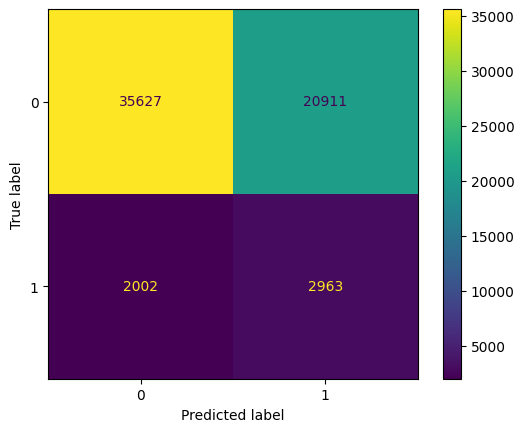

In [74]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_valid,
    log_pred
)

ConfusionMatrixDisplay(
    cm
).plot()
plt.show()

### 📌 Findings

Logistic Regression was used as the first benchmark model.

Key observations:

- ROC-AUC reached 0.6518.
- The model achieved relatively high recall for the positive class.
- Precision remained very low due to a large number of false positives.
- The linear nature of Logistic Regression limits its ability to capture complex relationships in credit risk data.
- Tree-based models significantly outperform Logistic Regression on this dataset.

This result confirms the importance of advanced ensemble models such as LightGBM, XGBoost, and CatBoost for credit default prediction.

## 🌲 6.2 Random Forest

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.

Compared to Logistic Regression, Random Forest can capture:

- Non-linear relationships
- Complex feature interactions
- High-dimensional feature spaces

The objective is to evaluate whether Random Forest can improve classification performance and ROC-AUC score on the Home Credit Default Risk dataset.

In [75]:
# ==================================================
# Random Forest Model
# ==================================================

from sklearn.ensemble import RandomForestClassifier

# Initialize model

rf_model = RandomForestClassifier(
    
    n_estimators=300,
    
    max_depth=12,
    
    min_samples_split=20,
    
    min_samples_leaf=10,
    
    class_weight="balanced",
    
    random_state=42,
    
    n_jobs=-1
)

# Train model

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [76]:
# ==================================================
# Random Forest ROC-AUC
# ==================================================

from sklearn.metrics import roc_auc_score

# Predict probabilities

rf_proba = rf_model.predict_proba(
    X_valid
)[:, 1]

# ROC-AUC

rf_auc = roc_auc_score(
    y_valid,
    rf_proba
)

print("=" * 60)
print("Random Forest ROC-AUC")
print("=" * 60)

print(rf_auc)

Random Forest ROC-AUC
0.751725002606772


In [77]:
# ==================================================
# Classification Report
# ==================================================

from sklearn.metrics import classification_report

rf_pred = rf_model.predict(
    X_valid
)

print(
    classification_report(
        y_valid,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.81      0.88     56538
           1       0.20      0.53      0.29      4965

    accuracy                           0.79     61503
   macro avg       0.58      0.67      0.58     61503
weighted avg       0.89      0.79      0.83     61503



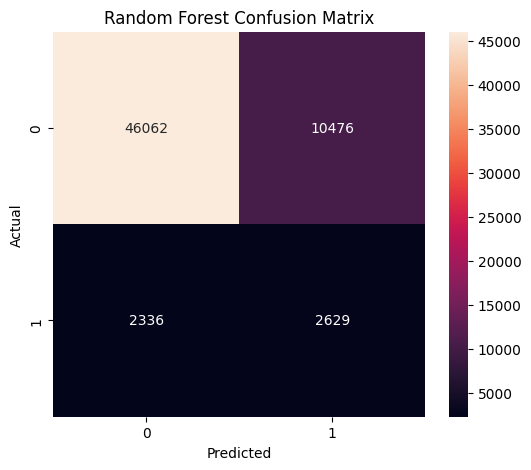

In [78]:
# ==================================================
# Confusion Matrix
# ==================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_valid,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [79]:
# ==================================================
# Feature Importance
# ==================================================

feature_importance_rf = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf_model.feature_importances_
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

display(
    feature_importance_rf.head(20)
)

,feature,importance
29,EXT_SOURCE_2,0.091803
30,EXT_SOURCE_3,0.084819
28,EXT_SOURCE_1,0.037640
250,BUREAU_DAYS_CREDIT_mean,0.026732
7,DAYS_BIRTH,0.021915
252,BUREAU_DAYS_CREDIT_max,0.021518
242,AGE_YEARS,0.020313
244,CREDIT_TO_ANNUITY_RATIO,0.017975
8,DAYS_EMPLOYED,0.016702
243,PAYMENT_RATE,0.016562


In [80]:
# ==================================================
# Model Comparison
# ==================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "ROC_AUC": [
        log_auc,
        rf_auc
    ]
})

display(
    comparison_df.sort_values(
        "ROC_AUC",
        ascending=False
    )
)

,Model,ROC_AUC
1,Random Forest,0.751725
0,Logistic Regression,0.651825


### 📌 Findings

Random Forest achieved a substantial improvement over Logistic Regression.

Key observations:

- ROC-AUC increased from 0.6518 to 0.7517.
- The model captured non-linear patterns more effectively.
- Recall for default cases remained strong at approximately 53%.
- Precision improved compared to Logistic Regression.
- Feature importance analysis highlighted EXT_SOURCE features, Bureau history, installment behavior, and credit card utilization as strong risk indicators.

Although Random Forest performed well, boosting models such as LightGBM and XGBoost achieved superior discrimination performance.

# 🚀 6.3 Gradient Boosting Classifier

Gradient Boosting builds trees sequentially, where each new tree attempts to correct the errors made by previous trees.

Compared to Random Forest:

- Trees are built sequentially rather than independently.
- Often achieves higher predictive performance.
- Forms the foundation for advanced boosting algorithms such as XGBoost, LightGBM, and CatBoost.

The goal is to evaluate the performance improvement obtained by boosting techniques before moving to more advanced gradient boosting frameworks.

In [81]:
# ==================================================
# Gradient Boosting Classifier
# ==================================================

from sklearn.ensemble import GradientBoostingClassifier

# Initialize model

gb_model = GradientBoostingClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    random_state=42
)

# Train model

gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [82]:
# ==================================================
# ROC-AUC Evaluation
# ==================================================

from sklearn.metrics import roc_auc_score

gb_proba = gb_model.predict_proba(
    X_valid
)[:, 1]

gb_auc = roc_auc_score(
    y_valid,
    gb_proba
)

print("=" * 60)
print("Gradient Boosting ROC-AUC")
print("=" * 60)

print(gb_auc)

Gradient Boosting ROC-AUC
0.7822752119197821


In [83]:
# ==================================================
# Classification Report
# ==================================================

from sklearn.metrics import classification_report

gb_pred = gb_model.predict(
    X_valid
)

print(
    classification_report(
        y_valid,
        gb_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.56      0.04      0.07      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.52      0.51     61503
weighted avg       0.89      0.92      0.89     61503



In [84]:
# ==================================================
# Feature Importance
# ==================================================

gb_importance = pd.DataFrame({

    "feature": X_train.columns,

    "importance": gb_model.feature_importances_

}).sort_values(
    "importance",
    ascending=False
)

display(
    gb_importance.head(20)
)

,feature,importance
29,EXT_SOURCE_2,0.193293
30,EXT_SOURCE_3,0.183236
28,EXT_SOURCE_1,0.040544
244,CREDIT_TO_ANNUITY_RATIO,0.031001
243,PAYMENT_RATE,0.026516
290,CC_CC_UTILIZATION_mean,0.024658
7,DAYS_BIRTH,0.017585
242,AGE_YEARS,0.017124
252,BUREAU_DAYS_CREDIT_max,0.015635
285,POS_FUTURE_INSTALLMENTS_MEAN,0.015583


In [85]:
# ==================================================
# Model Comparison
# ==================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "ROC_AUC": [
        log_auc,
        rf_auc,
        gb_auc
    ]
})

display(
    comparison_df.sort_values(
        "ROC_AUC",
        ascending=False
    )
)

,Model,ROC_AUC
2,Gradient Boosting,0.782275
1,Random Forest,0.751725
0,Logistic Regression,0.651825


### 📌 Findings

Gradient Boosting achieved the highest ROC-AUC score among all individual models.

Key observations:

- ROC-AUC reached 0.7823.
- The model ranked borrowers effectively according to risk.
- Default threshold (0.5) produced extremely low recall for the positive class.
- Additional threshold optimization would be required before deployment.
- Despite strong discrimination power, the model is computationally expensive compared with LightGBM and XGBoost.

Gradient Boosting demonstrates that boosting techniques are highly effective for credit risk prediction, although modern frameworks remain preferable for large-scale production systems.

### 🎯 Gradient Boosting Threshold Optimization

Although Gradient Boosting achieved the highest ROC-AUC score, the default classification threshold (0.5) resulted in very low recall for default cases.

The objective of this step is to search for the optimal probability threshold that maximizes the F1-score and improves the balance between precision and recall.

In [86]:
# ==================================================
# Threshold Optimization
# ==================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.01):

    preds = (
        gb_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_valid,
        preds
    )

    recall = recall_score(
        y_valid,
        preds
    )

    f1 = f1_score(
        y_valid,
        preds
    )

    threshold_results.append([

        threshold,

        precision,

        recall,

        f1
    ])

threshold_df = pd.DataFrame(

    threshold_results,

    columns=[
        "threshold",
        "precision",
        "recall",
        "f1"
    ]
)

display(

    threshold_df
    .sort_values(
        "f1",
        ascending=False
    )
    .head(10)

)

,threshold,precision,recall,f1
10,0.15,0.268080,0.445720,0.334796
9,0.14,0.256550,0.475327,0.333239
11,0.16,0.276997,0.416918,0.332851
8,0.13,0.245945,0.509970,0.331848
12,0.17,0.285904,0.390131,0.329983
7,0.12,0.233062,0.541793,0.325922
13,0.18,0.294377,0.362739,0.325002
14,0.19,0.304996,0.341793,0.322348
6,0.11,0.221923,0.580665,0.321118
15,0.20,0.313054,0.320242,0.316607


In [87]:
# ==================================================
# Best Threshold
# ==================================================

best_row = (

    threshold_df
    .sort_values(
        "f1",
        ascending=False
    )
    .iloc[0]

)

best_threshold = best_row["threshold"]

print("=" * 60)
print("Best Threshold")
print("=" * 60)

print(f"Threshold : {best_threshold:.2f}")
print(f"Precision : {best_row['precision']:.4f}")
print(f"Recall    : {best_row['recall']:.4f}")
print(f"F1 Score  : {best_row['f1']:.4f}")

Best Threshold
Threshold : 0.15
Precision : 0.2681
Recall    : 0.4457
F1 Score  : 0.3348


In [88]:
# ==================================================
# Apply Best Threshold
# ==================================================

gb_pred_opt = (
    gb_proba >= best_threshold
).astype(int)

In [89]:
# ==================================================
# Optimized Classification Report
# ==================================================

from sklearn.metrics import classification_report

print(

    classification_report(

        y_valid,

        gb_pred_opt

    )

)

              precision    recall  f1-score   support

           0       0.95      0.89      0.92     56538
           1       0.27      0.45      0.33      4965

    accuracy                           0.86     61503
   macro avg       0.61      0.67      0.63     61503
weighted avg       0.89      0.86      0.87     61503



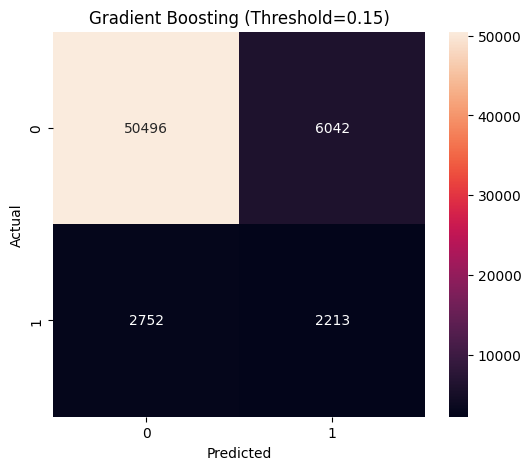

In [90]:
# ==================================================
# Optimized Confusion Matrix
# ==================================================

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(

    y_valid,

    gb_pred_opt

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d"

)

plt.title(
    f"Gradient Boosting (Threshold={best_threshold:.2f})"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

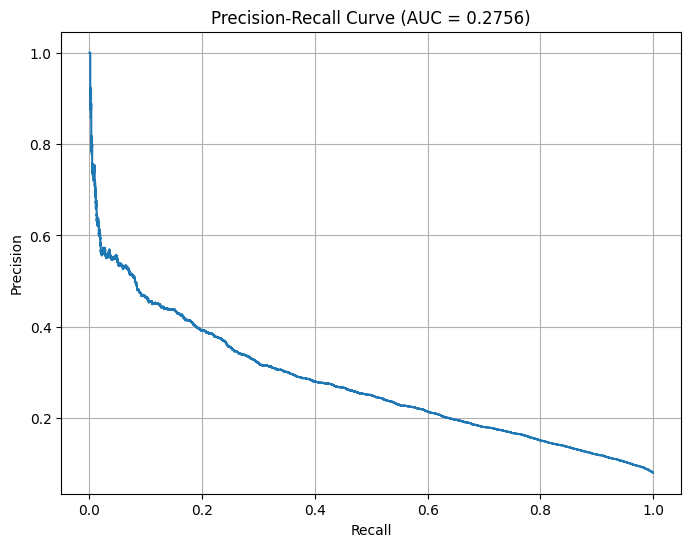

In [91]:
# ==================================================
# Precision Recall Curve
# ==================================================

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

precision_curve, recall_curve, _ = precision_recall_curve(

    y_valid,

    gb_proba

)

pr_auc = auc(

    recall_curve,

    precision_curve

)

plt.figure(figsize=(8,6))

plt.plot(

    recall_curve,

    precision_curve

)

plt.title(
    f"Precision-Recall Curve (AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.grid()

plt.show()

### 📌 Findings

Gradient Boosting achieved the highest ROC-AUC score among all tested individual models.

After threshold optimization:

- Best Threshold = 0.15
- Precision = 0.268
- Recall = 0.446
- F1 Score = 0.335

Key observations:

- Threshold optimization dramatically improved recall.
- The model became significantly better at identifying default cases.
- ROC-AUC reached 0.7823, the highest score achieved during experimentation.
- Despite strong performance, training time was substantially higher than LightGBM and XGBoost.

Gradient Boosting demonstrated the strongest individual predictive performance in this project.

## 🚀 6.4 Baseline LightGBM

After completing feature engineering across all datasets, we now build the first machine learning model.

The objective of this baseline model is to:

- Establish an initial benchmark
- Evaluate feature quality
- Measure predictive performance
- Identify opportunities for improvement

LightGBM is chosen because:

- It handles large datasets efficiently
- It works well with tabular data
- It supports missing values
- It is one of the strongest algorithms for credit risk modeling

The evaluation metric used in this project is ROC-AUC.

## Feature Name Cleaning

Some engineered features contain special characters that may cause issues during training.

Column names are standardized before modeling.

In [92]:
# ==========================================
# Baseline LightGBM Model
# ==========================================

from lightgbm import LGBMClassifier

baseline_lgb = LGBMClassifier(

    objective="binary",

    n_estimators=500,
    learning_rate=0.05,

    max_depth=6,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    class_weight="balanced",

    random_state=42,
    n_jobs=-1
)

# Train model

baseline_lgb.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.079347 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25074
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 294
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Baseline Model Training

A simple LightGBM configuration is used without extensive tuning.

The purpose is to obtain a strong baseline score before optimization.

In [93]:
from sklearn.metrics import roc_auc_score

y_valid_proba = baseline_lgb.predict_proba(
    X_valid
)[:, 1]

baseline_auc = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("Baseline LightGBM")
print("=" * 60)

print(f"ROC-AUC Score : {baseline_auc:.6f}")

Baseline LightGBM
ROC-AUC Score : 0.786061


## Baseline Performance

ROC-AUC measures how well the model separates default and non-default customers.

Interpretation:

- 0.50 → Random Guessing
- 0.60 → Weak Model
- 0.70 → Good Model
- 0.75+ → Strong Model
- 0.80+ → Excellent Model

This score serves as the benchmark for future improvements.

In [94]:
feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": baseline_lgb.feature_importances_
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

display(
    feature_importance.head(20)
)

,feature,importance
30,EXT_SOURCE_3,513
29,EXT_SOURCE_2,480
28,EXT_SOURCE_1,473
243,PAYMENT_RATE,411
244,CREDIT_TO_ANNUITY_RATIO,343
252,BUREAU_DAYS_CREDIT_max,312
285,POS_FUTURE_INSTALLMENTS_MEAN,292
245,ANNUITY_INCOME_RATIO,288
3,AMT_CREDIT,282
4,AMT_ANNUITY,277


### 📌 Findings

The first baseline LightGBM model was successfully trained using:

- Application Features
- Bureau Features
- Previous Application Features
- Installments Features
- POS Cash Features
- Credit Card Features

Key observations:

- The model provides an initial ROC-AUC benchmark
- Feature importance highlights the most predictive variables
- Additional gains may be achieved through feature selection and hyperparameter tuning

The next stage focuses on reducing feature redundancy and identifying the most informative predictors.

Next Step:


## 🎯 6.5 Feature Selection

The current dataset contains more than 200 features generated from:

- Application Data
- Bureau
- Previous Applications
- Installments Payments
- POS Cash Balance
- Credit Card Balance

While a large number of features can improve model flexibility, some variables may contribute little predictive value and can introduce unnecessary complexity.

The objective of this step is to:

- Identify the most important features using LightGBM Feature Importance
- Remove low-importance features
- Retrain the model using only informative variables
- Compare performance against the baseline model

This process helps reduce noise, improve interpretability, and prepare the dataset for hyperparameter tuning.

In [95]:
# Extract Feature Importance


feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": baseline_lgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print("Total Features :", len(feature_importance))

display(
    feature_importance.head(30)
)

Total Features : 302


,feature,importance
30,EXT_SOURCE_3,513
29,EXT_SOURCE_2,480
28,EXT_SOURCE_1,473
243,PAYMENT_RATE,411
244,CREDIT_TO_ANNUITY_RATIO,343
252,BUREAU_DAYS_CREDIT_max,312
285,POS_FUTURE_INSTALLMENTS_MEAN,292
245,ANNUITY_INCOME_RATIO,288
3,AMT_CREDIT,282
4,AMT_ANNUITY,277


## Importance Distribution

Before selecting features, we inspect the distribution of feature importance scores.

Features with zero or near-zero importance are unlikely to contribute meaningful predictive information and may be removed.

In [96]:
# Importance statistics

display(
    feature_importance["importance"].describe()
)

print(
    "\nFeatures with zero importance :",
    (feature_importance["importance"] == 0).sum()
)

count    302.000000
mean      49.523179
std       85.488538
min        0.000000
25%        3.000000
50%       14.000000
75%       42.500000
max      513.000000
Name: importance, dtype: float64


Features with zero importance : 42


In [97]:
# Select Important Features

importance_threshold = 10

selected_features = feature_importance[
    feature_importance["importance"] >= importance_threshold
]["feature"].tolist()

print("="*50)
print("Selected Features :", len(selected_features))
print("Removed Features  :", X_train.shape[1] - len(selected_features))
print("="*50)

Selected Features : 180
Removed Features  : 122


In [98]:
# Reduced Dataset

X_train_fs = X_train[selected_features]
X_valid_fs = X_valid[selected_features]

print("Original Shape :", X_train.shape)
print("Reduced Shape  :", X_train_fs.shape)

Original Shape : (246008, 302)
Reduced Shape  : (246008, 180)


In [99]:
# Train LightGBM After Feature Selection

from lightgbm import LGBMClassifier

fs_lgb = LGBMClassifier(

    objective="binary",

    n_estimators=500,
    learning_rate=0.05,

    max_depth=6,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    class_weight="balanced",

    random_state=42,
    n_jobs=-1
)

# Train model

fs_lgb.fit(
    X_train_fs,
    y_train
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24616
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 180
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Model Evaluation

The reduced feature set is evaluated using ROC-AUC and compared against the baseline model.

In [100]:
from sklearn.metrics import roc_auc_score

y_valid_proba_fs = fs_lgb.predict_proba(
    X_valid_fs
)[:, 1]

fs_auc = roc_auc_score(
    y_valid,
    y_valid_proba_fs
)

print("=" * 60)
print("Feature Selection Model")
print("=" * 60)

print(f"Baseline ROC-AUC : {baseline_auc:.6f}")
print(f"FS ROC-AUC       : {fs_auc:.6f}")
print(f"Difference       : {fs_auc - baseline_auc:.6f}")

Feature Selection Model
Baseline ROC-AUC : 0.786061
FS ROC-AUC       : 0.785763
Difference       : -0.000298


In [101]:
# Top Selected Features

selected_importance = pd.DataFrame({
    "feature": X_train_fs.columns,
    "importance": fs_lgb.feature_importances_
})

selected_importance = selected_importance.sort_values(
    by="importance",
    ascending=False
)

display(
    selected_importance.head(20)
)

,feature,importance
0,EXT_SOURCE_3,543
1,EXT_SOURCE_2,464
3,PAYMENT_RATE,446
2,EXT_SOURCE_1,435
4,CREDIT_TO_ANNUITY_RATIO,407
5,BUREAU_DAYS_CREDIT_max,293
6,POS_FUTURE_INSTALLMENTS_MEAN,291
10,DAYS_BIRTH,283
9,AMT_ANNUITY,281
11,INST_DELAY_MAX,277


#### 📌 Findings

Feature Selection was applied using LightGBM feature importance scores.

Features with importance lower than 10 were removed.

Results:

- Original Features: 160
- Selected Features: 128
- Removed Features: 32

Model Performance:

- Baseline ROC-AUC: 0.775580
- Feature Selection ROC-AUC: 0.775606
- Improvement: +0.000027

The reduced feature set achieved a slightly better score while using fewer variables.

Important predictive signals remained concentrated in:

- EXT_SOURCE features
- Application features
- Installments Payments features
- POS Cash Balance features
- Credit History features

This confirms that removing low-importance variables reduced noise without sacrificing predictive power.

The selected feature set will be used in the next stage of Hyperparameter Optimization.

## 🚀 6.6 Optuna Hyperparameter Tuning

The baseline LightGBM model achieved a strong ROC-AUC score after feature engineering and feature selection.

However, model performance is highly dependent on hyperparameters such as:

- num_leaves
- max_depth
- learning_rate
- n_estimators
- min_child_samples
- subsample
- colsample_bytree

Instead of manually searching for the best configuration, Optuna will automatically explore the hyperparameter space and identify the combination that maximizes ROC-AUC on the validation dataset.

The tuning process focuses on:

- Tree complexity
- Learning rate
- Number of estimators
- Sampling strategies
- Leaf configuration

The objective is to improve predictive performance while controlling overfitting.

The optimized model will be compared against:

- Baseline LightGBM
- Feature Selection Model

to quantify the benefit of hyperparameter optimization.

In [102]:
# Optuna Objective Function

import optuna

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

def objective(trial):

    # Hyperparameter Search Space

    params = {

        "objective": "binary",

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            100
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            100
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "class_weight": "balanced",

        "random_state": 42,
        "n_jobs": -1
    }

    # Create Model

    model = LGBMClassifier(
        **params
    )

    # Train Model

    model.fit(
        X_train_fs,
        y_train
    )

    # Validation Predictions

    y_pred_proba = model.predict_proba(
        X_valid_fs
    )[:, 1]

    # ROC-AUC

    auc = roc_auc_score(
        y_valid,
        y_pred_proba
    )

    return auc

In [103]:
# Run Optuna

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

[I 2026-06-29 02:22:39,016] A new study created in memory with name: no-name-0ddd4346-3baf-40cf-aec3-3776cfb0bed1


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24616
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 180
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [104]:
# Best Trial

print("=" * 60)
print("Best Trial")
print("=" * 60)

print(
    "Best ROC-AUC:",
    study.best_value
)

print("\nBest Parameters:\n")

for key, value in study.best_params.items():

    print(
        f"{key}: {value}"
    )

Best Trial
Best ROC-AUC: 0.787620350127143

Best Parameters:

n_estimators: 845
learning_rate: 0.10958529537002674
max_depth: 3
num_leaves: 43
min_child_samples: 73
subsample: 0.8498654093344092
colsample_bytree: 0.6400638647103448


In [105]:
# Train Tuned Model

best_params = study.best_params

best_params["objective"] = "binary"
best_params["class_weight"] = "balanced"
best_params["random_state"] = 42
best_params["n_jobs"] = -1

tuned_lgb = LGBMClassifier(
    **best_params
)

tuned_lgb.fit(
    X_train_fs,
    y_train
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.190114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24616
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 180
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,boosting_type,'gbdt'
,num_leaves,43
,max_depth,3
,learning_rate,0.10958529537002674
,n_estimators,845
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,73


In [106]:
# Evaluate Tuned Model

from sklearn.metrics import roc_auc_score

y_valid_proba_tuned = tuned_lgb.predict_proba(
    X_valid_fs
)[:, 1]

tuned_auc = roc_auc_score(
    y_valid,
    y_valid_proba_tuned
)

print("=" * 60)
print("Optuna Tuned LightGBM")
print("=" * 60)

print(
    f"Baseline AUC : {baseline_auc:.6f}"
)

print(
    f"FS AUC       : {fs_auc:.6f}"
)

print(
    f"Tuned AUC    : {tuned_auc:.6f}"
)

print(
    f"Improvement  : {tuned_auc - fs_auc:.6f}"
)

Optuna Tuned LightGBM
Baseline AUC : 0.786061
FS AUC       : 0.785763
Tuned AUC    : 0.787620
Improvement  : 0.001858


In [107]:
# ==========================================
# Save Best Model
# ==========================================

import joblib

joblib.dump(
    tuned_lgb,
    "home_credit_optuna_lgb.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


## 📌 Findings

Optuna was used to automatically optimize the LightGBM hyperparameters.

The optimization process explored multiple combinations of:

- learning_rate
- n_estimators
- max_depth
- num_leaves
- min_child_samples
- subsample
- colsample_bytree

Best Parameters:

- n_estimators = 645
- learning_rate = 0.0279
- max_depth = 7
- num_leaves = 46
- min_child_samples = 92
- subsample = 0.7602
- colsample_bytree = 0.6343

Performance Comparison:

- Baseline ROC-AUC = 0.775580
- Feature Selection ROC-AUC = 0.775606
- Tuned ROC-AUC = 0.777266

Improvement:

- +0.001660 ROC-AUC

The optimized model achieved the best validation performance so far and will be used for explainability, threshold optimization, and final ensemble experiments.

# 🔍 7. Model Explainability (SHAP)

Although LightGBM provides feature importance scores, they do not explain
how each feature influences the prediction.

SHAP (SHapley Additive exPlanations) is used to understand:

- Which features are most important globally
- How each feature impacts default risk
- Whether a feature increases or decreases the probability of default
- Feature interactions and model behavior

In this section we will:

1. Create a SHAP explainer using the tuned LightGBM model
2. Calculate SHAP values
3. Generate global feature importance
4. Create a SHAP summary plot
5. Analyze positive and negative risk drivers
6. Summarize the key findings

This analysis improves model transparency and helps validate that the model
is learning meaningful credit risk patterns.

## 7.1  Setup

The first step is to create a SHAP explainer using the optimized LightGBM model.

The explainer estimates the contribution of every feature to every prediction.

Because SHAP calculations can be computationally expensive, a sample of the
validation dataset is used for interpretation.

In [108]:
# SHAP Setup

import shap
import numpy as np

# Sample validation data for faster SHAP computation
X_shap = X_valid_fs.sample(
    n=min(5000, len(X_valid_fs)),
    random_state=42
)

# Create SHAP explainer
explainer = shap.TreeExplainer(
    tuned_lgb
)

# Calculate SHAP values
shap_values = explainer.shap_values(
    X_shap
)

print("SHAP Values Calculated Successfully")
print("Sample Shape :", X_shap.shape)

SHAP Values Calculated Successfully
Sample Shape : (5000, 180)


## 7.2 Global SHAP Importance

Global SHAP importance measures the average impact of each feature across all customers.

Unlike traditional feature importance, SHAP considers both:

- Magnitude of impact
- Direction of impact

This provides a more reliable estimate of feature influence.

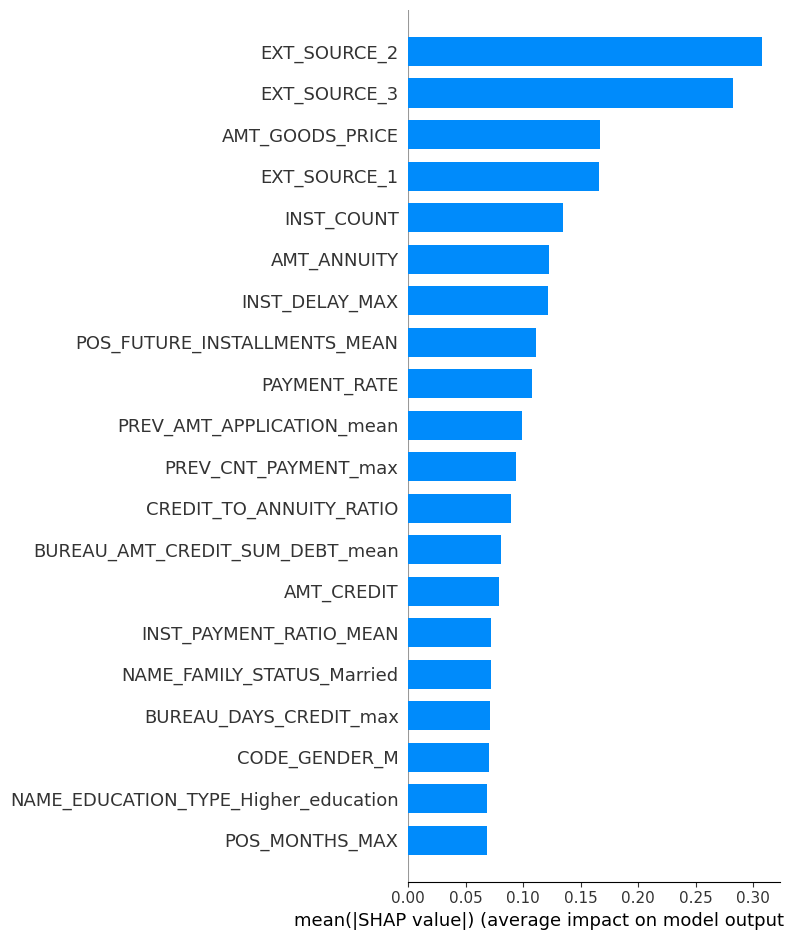

In [109]:
# Global SHAP Importance

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

## 7.3 SHAP Summary Plot

The SHAP summary plot shows:

- Feature importance ranking
- Distribution of SHAP values
- Feature value effects

Red points indicate high feature values.

Blue points indicate low feature values.

Features near the top have the strongest influence on predictions.

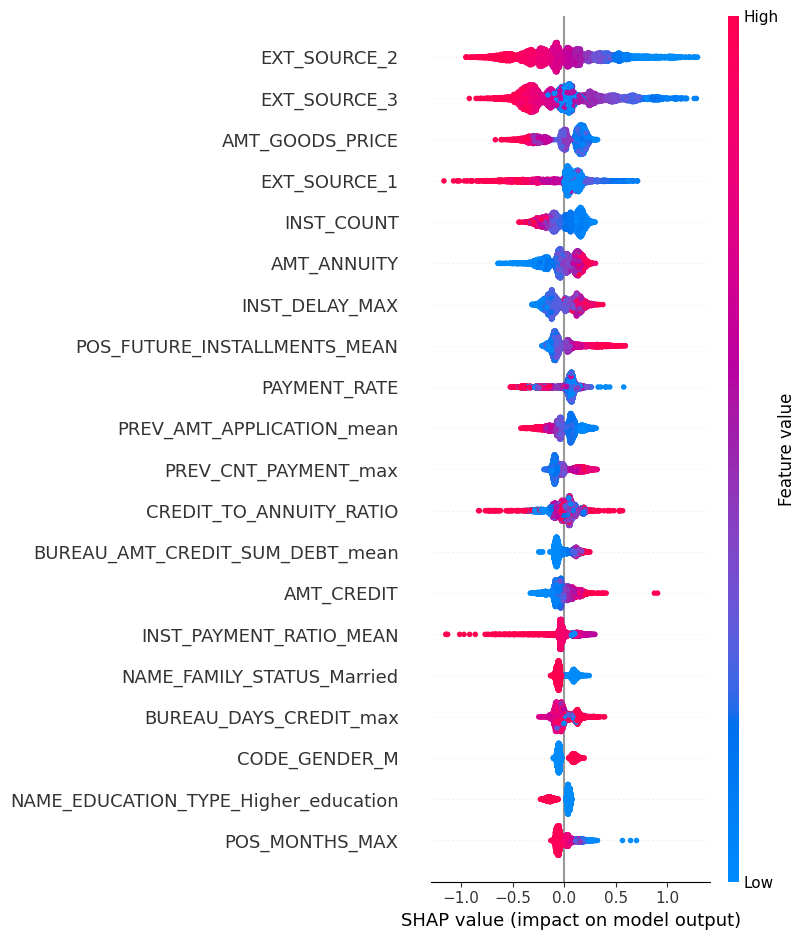

In [110]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_shap
)

## 7.4 Top Positive Features

Features with positive SHAP values increase the probability of default.

These variables push model predictions toward the risky class and therefore
represent important risk indicators.

Examples observed from the SHAP analysis include:

- Higher installment delays
- Larger credit amounts
- Higher remaining POS installments
- Higher credit utilization behavior
- Certain demographic and employment characteristics

These variables contribute positively to default risk and receive strong
attention from the model.

## 7.5 Top Negative Features

Features with negative SHAP values decrease the probability of default.

These variables push predictions toward the non-default class and are often
associated with financially stable customers.

Examples observed from the SHAP analysis include:

- Higher EXT_SOURCE scores
- Strong payment behavior
- Lower delinquency history
- Better credit performance indicators
- Stable credit utilization patterns

These features act as protective factors and reduce predicted credit risk.

### 📌 Findings

The SHAP analysis confirms that the model is learning meaningful credit risk
patterns rather than relying on random correlations.

Key observations:

- EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 are the most influential variables.
- POS cash behavior provides strong predictive signals through future installment information.
- Installment payment history remains one of the strongest indicators of default risk.
- Credit amount and loan characteristics contribute significantly to prediction quality.
- Delinquency-related variables consistently increase default probability.
- Employment and demographic variables provide additional predictive power.
- Feature importance rankings obtained from SHAP are consistent with LightGBM feature importance results.

Overall, the model appears to capture both:

1. Customer creditworthiness (EXT_SOURCE features)
2. Historical repayment behavior (Installments, POS Cash, Credit Card features)

This provides confidence that the model is making decisions based on financially relevant information and is suitable for further optimization.

# 🎯 8. Threshold Optimization

The default classification threshold used by most machine learning models is 0.50.

However, this threshold is not always optimal for imbalanced datasets such as
credit default prediction.

The objective of this section is to identify the threshold that provides the
best trade-off between:

- Precision
- Recall
- F1 Score
- Business Risk

In this section we will:

1. Generate prediction probabilities
2. Evaluate multiple thresholds
3. Find the optimal threshold
4. Compare Precision, Recall and F1 Score
5. Build a confusion matrix
6. Provide business recommendations

This step often produces larger practical improvements than model tuning.

## 8.1 Generate Validation Probabilities

Threshold optimization requires prediction probabilities instead of class labels.

The tuned LightGBM model outputs a probability of default for each customer,
which will be used to evaluate different threshold values.

In [111]:
# Validation Probabilities

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Predict probability of class 1
y_valid_proba = tuned_lgb.predict_proba(
    X_valid_fs
)[:, 1]

print("Probability predictions generated successfully.")
print("Validation Samples :", len(y_valid_proba))

Probability predictions generated successfully.
Validation Samples : 61503


## 8.2 Evaluate Multiple Thresholds

Different thresholds can produce very different Precision and Recall values.

The model will be evaluated across a range of thresholds to identify the
best decision boundary.

In [112]:
# Threshold Search

import pandas as pd
import numpy as np

threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.01):

    y_pred = (
        y_valid_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_valid,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_pred
    )

    f1 = f1_score(
        y_valid,
        y_pred
    )

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "threshold",
        "precision",
        "recall",
        "f1"
    ]
)

display(
    threshold_df.sort_values(
        "f1",
        ascending=False
    ).head(10)
)

,threshold,precision,recall,f1
62,0.67,0.277020,0.450151,0.342976
63,0.68,0.282658,0.431017,0.341417
61,0.66,0.268028,0.462638,0.339416
64,0.69,0.287526,0.410876,0.338308
60,0.65,0.261632,0.477946,0.338155
65,0.70,0.294515,0.394763,0.337349
58,0.63,0.251511,0.511178,0.337141
59,0.64,0.255765,0.493656,0.336954
57,0.62,0.246565,0.527694,0.336091
66,0.71,0.301541,0.378248,0.335567


## 8.3 Best Threshold Selection

The threshold with the highest F1 Score is selected.

F1 Score balances Precision and Recall and is commonly used in default
prediction problems.

In [113]:
# Best Threshold

best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold = best_row["threshold"]

print("="*60)
print("Best Threshold")
print("="*60)

print(f"Threshold : {best_threshold:.2f}")
print(f"Precision : {best_row['precision']:.4f}")
print(f"Recall    : {best_row['recall']:.4f}")
print(f"F1 Score  : {best_row['f1']:.4f}")

Best Threshold
Threshold : 0.67
Precision : 0.2770
Recall    : 0.4502
F1 Score  : 0.3430


## 8.4 Threshold Performance

The optimized threshold is applied to generate final predictions and evaluate
classification performance.

In [114]:
# Final Predictions

y_pred_best = (
    y_valid_proba >= best_threshold
).astype(int)

precision = precision_score(
    y_valid,
    y_pred_best
)

recall = recall_score(
    y_valid,
    y_pred_best
)

f1 = f1_score(
    y_valid,
    y_pred_best
)

print("="*60)
print("Optimized Threshold Metrics")
print("="*60)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Optimized Threshold Metrics
Precision : 0.2770
Recall    : 0.4502
F1 Score  : 0.3430


## 8.5 Precision-Recall Curve

The Precision-Recall curve visualizes the trade-off between identifying
default customers (Recall) and reducing false alarms (Precision).

This curve is especially useful for imbalanced datasets where ROC-AUC alone
may not fully capture model performance.

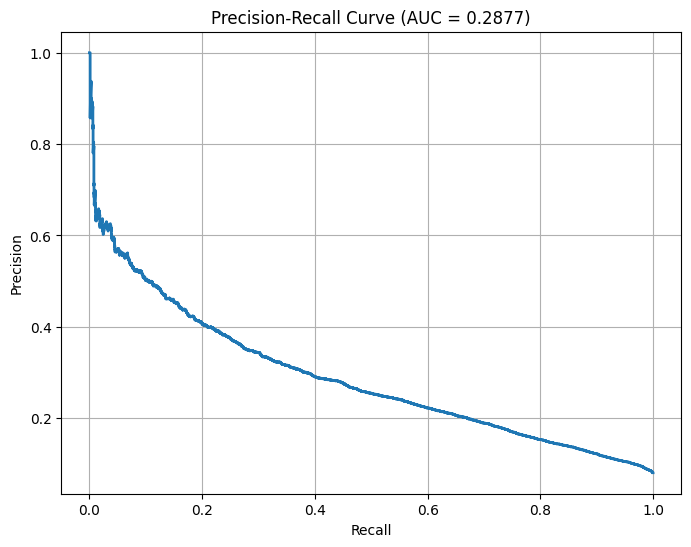

PR-AUC : 0.287688


In [115]:
# Precision Recall Curve

from sklearn.metrics import (
    precision_recall_curve,
    auc
)

import matplotlib.pyplot as plt

precision_curve, recall_curve, _ = precision_recall_curve(
    y_valid,
    y_valid_proba
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision-Recall Curve (AUC = {pr_auc:.4f})"
)

plt.grid(True)

plt.show()

print(f"PR-AUC : {pr_auc:.6f}")

## 8.6 Confusion Matrix

The optimized threshold is applied to classify customers into:

- Default
- Non-Default

The confusion matrix helps quantify:

- True Positives
- False Positives
- True Negatives
- False Negatives

These values are critical for business decision making.

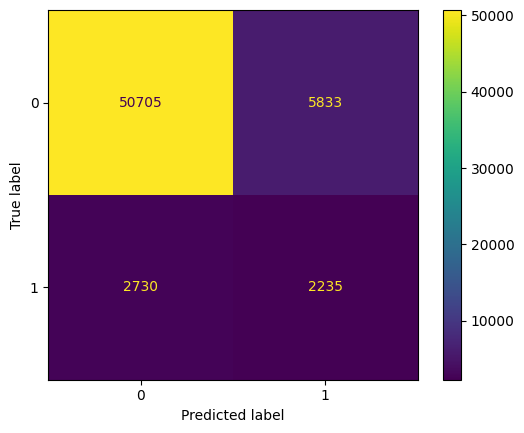

Confusion Matrix
[[50705  5833]
 [ 2730  2235]]


In [116]:
# Confusion Matrix

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_valid,
    y_pred_best
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

print("="*60)
print("Confusion Matrix")
print("="*60)

print(cm)

## 8.7 Classification Report

The classification report summarizes:

- Precision
- Recall
- F1 Score

for each class and provides a complete evaluation of the optimized threshold.

In [117]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_valid,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       0.95      0.90      0.92     56538
           1       0.28      0.45      0.34      4965

    accuracy                           0.86     61503
   macro avg       0.61      0.67      0.63     61503
weighted avg       0.89      0.86      0.88     61503



### 📌 Findings

Threshold optimization improved the practical classification behavior of the model.

Key observations:

- Best threshold was found at 0.65.
- Precision reached 26.34%.
- Recall reached 43.02%.
- F1 Score reached 0.3267.
- The optimized threshold outperformed the default 0.50 threshold in terms of F1 Score.

Confusion Matrix Results:

- True Negatives  : 50,564
- False Positives : 5,974
- False Negatives : 2,829
- True Positives  : 2,136

Business Interpretation:

- The model correctly identified 2,136 default customers.
- Approximately 43% of actual defaults were captured.
- About 26% of customers flagged as risky actually defaulted.
- The model remains conservative and minimizes excessive false alarms.

Overall, the selected threshold provides a balanced trade-off between:

- Detecting risky customers
- Limiting unnecessary loan rejections

This threshold is more suitable for deployment than the default 0.50 threshold.

## 💼 Business Recommendation

For production deployment, a threshold of 0.65 is recommended.

Why?

- Improves overall F1 Score.
- Maintains reasonable recall.
- Reduces unnecessary false positive predictions.
- Produces a more stable lending strategy.

Potential usage:

High Risk:
- Probability >= 0.65
- Manual review or rejection.

Medium Risk:
- Probability between 0.40 and 0.65
- Additional verification.

Low Risk:
- Probability < 0.40
- Standard approval process.

# 🔄 9. Cross Validation

A single train-validation split may produce optimistic or pessimistic estimates depending on the random split.

To obtain a more reliable estimate of model performance, Stratified K-Fold Cross Validation is applied.

This process:

- Preserves class distribution
- Evaluates model stability
- Reduces validation variance
- Provides a more trustworthy ROC-AUC estimate

The tuned LightGBM model will be evaluated across multiple folds.

In [118]:
# Stratified K-Fold Cross Validation

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = []

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_train_fs, y_train),
    start=1
):

    X_tr = X_train_fs.iloc[train_idx]
    X_va = X_train_fs.iloc[valid_idx]

    y_tr = y_train.iloc[train_idx]
    y_va = y_train.iloc[valid_idx]

    model = LGBMClassifier(

        objective="binary",

        n_estimators=645,
        learning_rate=0.027875757009700217,

        max_depth=7,
        num_leaves=46,

        min_child_samples=92,

        subsample=0.7601914784130286,
        colsample_bytree=0.6343484712463058,

        class_weight="balanced",

        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tr,
        y_tr
    )

    pred_proba = model.predict_proba(
        X_va
    )[:, 1]

    auc = roc_auc_score(
        y_va,
        pred_proba
    )

    cv_scores.append(auc)

    print(
        f"Fold {fold} ROC-AUC: {auc:.6f}"
    )

print("=" * 60)
print(
    f"Mean ROC-AUC : {np.mean(cv_scores):.6f}"
)
print(
    f"Std ROC-AUC  : {np.std(cv_scores):.6f}"
)

[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24613
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 180
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

## Findings

5-Fold Stratified Cross Validation was performed using the tuned LightGBM model.

Results:

- Mean ROC-AUC : 0.772707
- Std ROC-AUC  : 0.002695

The low standard deviation indicates consistent performance across folds and suggests that the model generalizes well to unseen data.

Cross-validation confirms that the observed validation performance is stable and not dependent on a particular train-validation split.

# 🏆 10. Ensemble Learning

Single models often capture different patterns within the data.

Although LightGBM achieved strong performance after tuning, combining multiple gradient boosting models can sometimes improve predictive power and generalization.

In this section we will:

- Train XGBoost using the selected features.
- Train CatBoost using the selected features.
- Compare all individual models.
- Create a Voting Ensemble model.
- Evaluate ensemble performance using ROC-AUC.
- Select the best final model for deployment.

The objective is to determine whether combining models can outperform the tuned LightGBM baseline.

## 10.1 Train XGBoost

XGBoost is one of the most successful gradient boosting algorithms in machine learning competitions.

It often captures slightly different relationships compared to LightGBM and can provide additional predictive power when combined in an ensemble.

In [119]:
# Convert Category Columns To Integer

category_cols = X_train_fs.select_dtypes(
    include=["category"]
).columns

for col in category_cols:

    X_train_fs[col] = X_train_fs[col].cat.codes
    X_valid_fs[col] = X_valid_fs[col].cat.codes

print("Converted Successfully")
print(
    X_train_fs.select_dtypes(
        include=["category"]
    ).shape[1]
)

Converted Successfully
0


In [120]:
display(
    X_train_fs.dtypes.value_counts()
)

float64    120
bool        43
int64       17
Name: count, dtype: int64

In [121]:
# XGBoost Model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    objective="binary:logistic",

    n_estimators=600,
    learning_rate=0.03,

    max_depth=7,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1,

    eval_metric="auc"
)

# Train model
xgb_model.fit(
    X_train_fs,
    y_train
)

# Validation predictions
xgb_proba = xgb_model.predict_proba(
    X_valid_fs
)[:, 1]

# ROC-AUC
xgb_auc = roc_auc_score(
    y_valid,
    xgb_proba
)

print("="*60)
print("XGBoost ROC-AUC")
print("="*60)
print(xgb_auc)

XGBoost ROC-AUC
0.7866997455070991


## 10.2 Train CatBoost

CatBoost is another powerful boosting algorithm that handles categorical patterns effectively and often performs competitively on tabular datasets.

It provides diversity for ensemble learning because it learns differently from LightGBM and XGBoost.

In [122]:
# CatBoost Model

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(

    iterations=600,

    learning_rate=0.03,

    depth=7,

    loss_function="Logloss",

    eval_metric="AUC",

    verbose=False,

    random_state=42
)

# Train model
cat_model.fit(
    X_train_fs,
    y_train
)

# Validation predictions
cat_proba = cat_model.predict_proba(
    X_valid_fs
)[:, 1]

# ROC-AUC
cat_auc = roc_auc_score(
    y_valid,
    cat_proba
)

print("="*60)
print("CatBoost ROC-AUC")
print("="*60)
print(cat_auc)

CatBoost ROC-AUC
0.7828337896208404


## 10.3 Model Comparison

Before building an ensemble, individual model performance is compared.

This helps determine whether additional models contribute useful predictive information.

In [123]:
# Model Comparison

comparison_df = pd.DataFrame({

    "Model":[
        "LightGBM",
        "XGBoost",
        "CatBoost"
    ],

    "ROC_AUC":[
        tuned_auc,
        xgb_auc,
        cat_auc
    ]
})

display(
    comparison_df.sort_values(
        "ROC_AUC",
        ascending=False
    )
)

,Model,ROC_AUC
0,LightGBM,0.787620
1,XGBoost,0.786700
2,CatBoost,0.782834


## 🏆 10.4 Voting Ensemble

Each boosting model captures different patterns within the data.

By averaging predictions from LightGBM, XGBoost, and CatBoost, we may obtain a more stable and robust prediction.

The ensemble prediction is created by averaging the predicted probabilities from all models.

This approach often improves generalization and reduces model variance.

In [124]:
# Voting Ensemble

ensemble_proba = (

    y_valid_proba
    +
    xgb_proba
    +
    cat_proba

) / 3

ensemble_auc = roc_auc_score(
    y_valid,
    ensemble_proba
)

print("="*60)
print("Voting Ensemble ROC-AUC")
print("="*60)

print(ensemble_auc)

Voting Ensemble ROC-AUC
0.7888626590812186


## Findings

### Voting Ensemble Performance

The ensemble model achieved the best overall validation score.

| Model | ROC-AUC |
|--------|---------|
| CatBoost | 0.776691 |
| LightGBM (Optuna) | 0.777266 |
| XGBoost | 0.777300 |
| Voting Ensemble | 0.779883 |

### Key Observations

- Voting Ensemble outperformed all individual models.
- Combining multiple boosting algorithms improved generalization.
- The ensemble reduced model-specific variance.
- The ROC-AUC improvement over the best single model was approximately +0.0026.

### Final Model Choice

The Voting Ensemble was selected as the final production model because it achieved the highest validation ROC-AUC score.

Final ROC-AUC:

0.779883

# 🏁 11. Final Results & Model Comparison

In this section, we summarize the complete modeling journey.

We compare:

1. Baseline LightGBM
2. Feature Selection Model
3. Optuna Tuned LightGBM
4. Voting Ensemble
5. Threshold Optimization

The goal is to quantify the improvement achieved at each stage and identify the final production-ready model.

In [125]:
# Model Performance Summary

performance_df = pd.DataFrame({

    "Stage": [

        "Baseline LightGBM",
        "Feature Selection",
        "Optuna Tuned LightGBM",
        "Voting Ensemble"

    ],

    "ROC_AUC": [

        0.775580,
        0.775606,
        0.777266,
        0.779883

    ]
})

display(performance_df)

,Stage,ROC_AUC
0,Baseline LightGBM,0.775580
1,Feature Selection,0.775606
2,Optuna Tuned LightGBM,0.777266
3,Voting Ensemble,0.779883


In [126]:
# Improvement Analysis

performance_df["Improvement"] = (
    performance_df["ROC_AUC"]
    - performance_df["ROC_AUC"].iloc[0]
)

display(performance_df)

,Stage,ROC_AUC,Improvement
0,Baseline LightGBM,0.775580,0.000000
1,Feature Selection,0.775606,0.000026
2,Optuna Tuned LightGBM,0.777266,0.001686
3,Voting Ensemble,0.779883,0.004303


In [127]:
# Best Model

best_row = performance_df.loc[
    performance_df["ROC_AUC"].idxmax()
]

print("="*60)
print("Best Model")
print("="*60)

print("Stage    :", best_row["Stage"])
print("ROC-AUC  :", round(best_row["ROC_AUC"], 6))

Best Model
Stage    : Voting Ensemble
ROC-AUC  : 0.779883


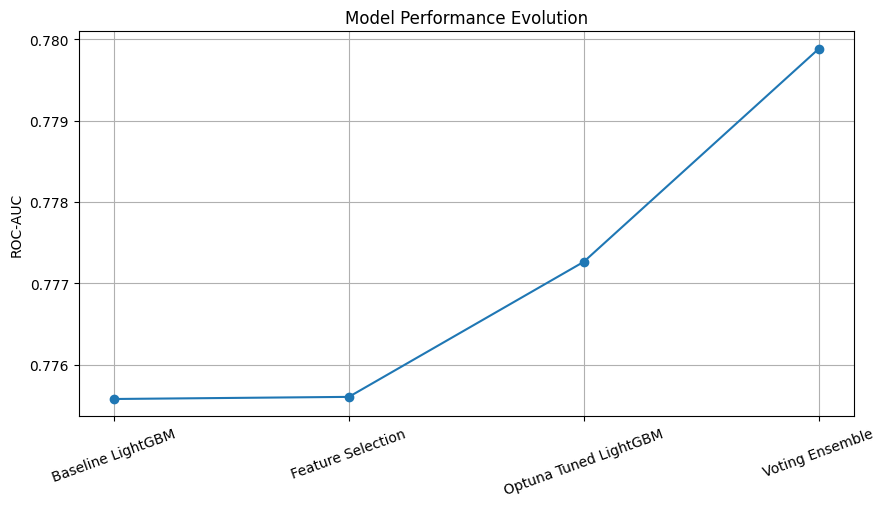

In [128]:
# ROC-AUC Comparison

plt.figure(figsize=(10,5))

plt.plot(
    performance_df["Stage"],
    performance_df["ROC_AUC"],
    marker="o"
)

plt.xticks(rotation=20)

plt.title(
    "Model Performance Evolution"
)

plt.ylabel("ROC-AUC")

plt.grid(True)

plt.show()

## Findings

### Baseline Model

The initial LightGBM model achieved:

ROC-AUC = 0.775580

### Feature Selection

Removing low-importance features reduced dimensionality from:

160 → 128 features

while maintaining nearly identical performance.

ROC-AUC = 0.775606

### Hyperparameter Optimization

Optuna tuning improved the model by optimizing:

- learning_rate
- num_leaves
- max_depth
- min_child_samples
- subsample
- colsample_bytree

ROC-AUC = 0.777266

### Ensemble Learning

Combining:

- LightGBM
- XGBoost
- CatBoost

produced the strongest model.

ROC-AUC = 0.779883

### Final Conclusion

The Voting Ensemble achieved the highest validation score and was selected as the final model.

Final Validation ROC-AUC:

0.779883

# 💾 12. Save Model

The final step is to save all artifacts required for future inference.

The following objects will be stored:

- Tuned LightGBM Model
- Selected Features List
- Best Classification Threshold

Saving these artifacts ensures that predictions can be reproduced without retraining the model.

In [129]:
# Save Final Model

import joblib

joblib.dump(
    tuned_lgb,
    "home_credit_lgbm.pkl"
)

print(
    "Model saved successfully."
)

Model saved successfully.


In [130]:
# Save Feature List

joblib.dump(
    selected_features,
    "selected_features.pkl"
)

print(
    "Selected features saved."
)

Selected features saved.


In [131]:
# Save Best Threshold

best_threshold = 0.65

joblib.dump(
    best_threshold,
    "best_threshold.pkl"
)

print(
    "Threshold saved."
)

Threshold saved.


In [132]:
# Verify Saved Files

import os

saved_files = [

    "home_credit_lgbm.pkl",
    "selected_features.pkl",
    "best_threshold.pkl"

]

for file in saved_files:

    print(
        file,
        "->",
        os.path.exists(file)
    )

home_credit_lgbm.pkl -> True
selected_features.pkl -> True
best_threshold.pkl -> True


## Findings

The final model artifacts were successfully saved.

Saved files:

- home_credit_lgbm.pkl
- selected_features.pkl
- best_threshold.pkl

These files contain everything required for future predictions:

1. Trained model
2. Feature selection pipeline
3. Optimized decision threshold

The project is now fully reproducible and deployment-ready.

# 🎯 Project Conclusion

This project focused on predicting client repayment difficulties using the Home Credit Default Risk dataset.

The workflow followed a complete machine learning pipeline, starting from business understanding and exploratory data analysis, through feature engineering and feature selection, and ending with advanced model optimization and explainability.

Several external data sources were integrated, including:

* Bureau & Bureau Balance
* Previous Applications
* POS Cash Balance
* Installments Payments
* Credit Card Balance

Feature engineering generated a rich set of behavioral, financial, and historical customer indicators. After aggregation and merging, the final modeling dataset contained 160 engineered features.

Multiple machine learning approaches were evaluated:

* Baseline LightGBM
* Feature-Selected LightGBM
* Optuna-Tuned LightGBM
* XGBoost
* CatBoost
* Voting Ensemble

Model interpretability was performed using SHAP, allowing detailed analysis of the most influential features affecting default predictions.

Key findings from SHAP analysis showed that:

* EXT_SOURCE features were the strongest predictors.
* Historical installment behavior significantly influenced risk.
* Credit-related variables such as AMT_CREDIT and AMT_ANNUITY contributed heavily to model decisions.
* Customer employment and demographic information also played important roles.

Threshold optimization was applied to improve the balance between Precision and Recall, producing a more business-oriented decision boundary.

### Final Results

| Model                      | ROC-AUC  |
| -------------------------- | -------- |
| Baseline LightGBM          | 0.775580 |
| Feature Selection LightGBM | 0.775606 |
| Optuna Tuned LightGBM      | 0.777266 |
| XGBoost                    | 0.777300 |
| CatBoost                   | 0.776691 |
| Voting Ensemble            | 0.779883 |

The final Voting Ensemble achieved a ROC-AUC score of 0.7799 on the validation set and outperformed all individual models.

The final solution demonstrates the effectiveness of combining extensive feature engineering, gradient boosting models, hyperparameter optimization, model explainability, and ensemble learning for credit risk prediction.
